In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from tensorflow.keras.layers import Dense, Flatten, Input, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from keras.models import Sequential
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [3]:
#import splitfolders # or import splitfolders
#input_folder = "Garbage classification"
#output = "output/" #where you want the split datasets saved. one will be created if it does not exist or none is set

#splitfolders.ratio(input_folder, output=output, seed=42, ratio=(.7, .3,)) # ratio of split are in order of train/val/test. You can change to whatever you want. For train/val sets only, you could do .75, .25 for example.

In [4]:
train_path = "output/train"
test_path = "output/val"

In [5]:
IMAGE_SIZE = [128,128]

In [6]:
# Scaling all the images between 0 to 1

train_datagen = ImageDataGenerator(rescale = 1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=False)

# Performing only scaling on the test dataset

test_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
train_set = train_datagen.flow_from_directory(train_path,
                                              target_size=(128,128),
                                              batch_size=2,
                                              class_mode = 'categorical')

test_set = test_datagen.flow_from_directory(test_path,
                                            target_size=(128,128),
                                            batch_size=2,
                                            class_mode='categorical')

Found 1766 images belonging to 6 classes.
Found 761 images belonging to 6 classes.


In [8]:
from keras import backend as K

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [9]:
from keras.metrics import Precision, Recall
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential, Model

learning_rate_reduction = ReduceLROnPlateau(
    monitor="val_accuracy", patience=3, verbose=1, factor=0.3, min_lr=0.0000001
)
early_stop = EarlyStopping(
    patience=20,
    verbose=1,
    monitor="val_accuracy",
    mode="max",
    min_delta=0.001,
    restore_best_weights=True,
)

In [10]:
from tensorflow.keras.applications import ResNet50, InceptionV3, MobileNetV2, DenseNet201,NASNetMobile

In [2]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

# InceptionV3

In [12]:
base_model = InceptionV3(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(6, activation='softmax')(x1)
model1 = Model(inputs = base_model.inputs, outputs = prediction1)
model1.summary()
model1.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 63, 63, 32)   864         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 63, 63, 32)  96          ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                              

 batch_normalization_10 (BatchN  (None, 13, 13, 96)  288         ['conv2d_10[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_11 (BatchN  (None, 13, 13, 32)  96          ['conv2d_11[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_5 (Activation)      (None, 13, 13, 64)   0           ['batch_normalization_5[0][0]']  
                                                                                                  
 activation_7 (Activation)      (None, 13, 13, 64)   0           ['batch_normalization_7[0][0]']  
                                                                                                  
 activatio

 conv2d_20 (Conv2D)             (None, 13, 13, 48)   13824       ['mixed1[0][0]']                 
                                                                                                  
 conv2d_23 (Conv2D)             (None, 13, 13, 96)   55296       ['activation_22[0][0]']          
                                                                                                  
 batch_normalization_20 (BatchN  (None, 13, 13, 48)  144         ['conv2d_20[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_23 (BatchN  (None, 13, 13, 96)  288         ['conv2d_23[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activatio

                                                                                                  
 conv2d_34 (Conv2D)             (None, 6, 6, 128)    98304       ['mixed3[0][0]']                 
                                                                                                  
 batch_normalization_34 (BatchN  (None, 6, 6, 128)   384         ['conv2d_34[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_34 (Activation)     (None, 6, 6, 128)    0           ['batch_normalization_34[0][0]'] 
                                                                                                  
 conv2d_35 (Conv2D)             (None, 6, 6, 128)    114688      ['activation_34[0][0]']          
                                                                                                  
 batch_nor

                                                                                                  
 activation_44 (Activation)     (None, 6, 6, 160)    0           ['batch_normalization_44[0][0]'] 
                                                                                                  
 conv2d_45 (Conv2D)             (None, 6, 6, 160)    179200      ['activation_44[0][0]']          
                                                                                                  
 batch_normalization_45 (BatchN  (None, 6, 6, 160)   480         ['conv2d_45[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_45 (Activation)     (None, 6, 6, 160)    0           ['batch_normalization_45[0][0]'] 
                                                                                                  
 conv2d_41

 batch_normalization_55 (BatchN  (None, 6, 6, 160)   480         ['conv2d_55[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_55 (Activation)     (None, 6, 6, 160)    0           ['batch_normalization_55[0][0]'] 
                                                                                                  
 conv2d_51 (Conv2D)             (None, 6, 6, 160)    122880      ['mixed5[0][0]']                 
                                                                                                  
 conv2d_56 (Conv2D)             (None, 6, 6, 160)    179200      ['activation_55[0][0]']          
                                                                                                  
 batch_normalization_51 (BatchN  (None, 6, 6, 160)   480         ['conv2d_51[0][0]']              
 ormalizat

 conv2d_61 (Conv2D)             (None, 6, 6, 192)    147456      ['mixed6[0][0]']                 
                                                                                                  
 conv2d_66 (Conv2D)             (None, 6, 6, 192)    258048      ['activation_65[0][0]']          
                                                                                                  
 batch_normalization_61 (BatchN  (None, 6, 6, 192)   576         ['conv2d_61[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_66 (BatchN  (None, 6, 6, 192)   576         ['conv2d_66[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activatio

 ormalization)                                                                                    
                                                                                                  
 batch_normalization_74 (BatchN  (None, 6, 6, 192)   576         ['conv2d_74[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_70 (Activation)     (None, 6, 6, 192)    0           ['batch_normalization_70[0][0]'] 
                                                                                                  
 activation_74 (Activation)     (None, 6, 6, 192)    0           ['batch_normalization_74[0][0]'] 
                                                                                                  
 conv2d_71 (Conv2D)             (None, 2, 2, 320)    552960      ['activation_70[0][0]']          
          

                                                                                                  
 activation_82 (Activation)     (None, 2, 2, 384)    0           ['batch_normalization_82[0][0]'] 
                                                                                                  
 activation_83 (Activation)     (None, 2, 2, 384)    0           ['batch_normalization_83[0][0]'] 
                                                                                                  
 batch_normalization_84 (BatchN  (None, 2, 2, 192)   576         ['conv2d_84[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_76 (Activation)     (None, 2, 2, 320)    0           ['batch_normalization_76[0][0]'] 
                                                                                                  
 mixed9_0 

 ormalization)                                                                                    
                                                                                                  
 activation_85 (Activation)     (None, 2, 2, 320)    0           ['batch_normalization_85[0][0]'] 
                                                                                                  
 mixed9_1 (Concatenate)         (None, 2, 2, 768)    0           ['activation_87[0][0]',          
                                                                  'activation_88[0][0]']          
                                                                                                  
 concatenate_1 (Concatenate)    (None, 2, 2, 768)    0           ['activation_91[0][0]',          
                                                                  'activation_92[0][0]']          
                                                                                                  
 activatio

In [13]:
hist1 = model1.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set))#,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
883/883 [==============================] - 51s 50ms/step - loss: 3.0517 - accuracy: 0.1976 - f1_m: 0.1183 - precision_m: 0.1478 - recall_m: 0.1036 - val_loss: 16.1740 - val_accuracy: 0.2208 - val_f1_m: 0.0656 - val_precision_m: 0.0919 - val_recall_m: 0.0525
Epoch 2/100
883/883 [==============================] - 42s 48ms/step - loss: 2.1768 - accuracy: 0.2220 - f1_m: 0.1080 - precision_m: 0.1518 - recall_m: 0.0861 - val_loss: 42.4525 - val_accuracy: 0.0841 - val_f1_m: 0.0490 - val_precision_m: 0.0709 - val_recall_m: 0.0381
Epoch 3/100
883/883 [==============================] - 42s 47ms/step - loss: 1.9987 - accuracy: 0.2191 - f1_m: 0.0740 - precision_m: 0.1076 - recall_m: 0.0572 - val_loss: 94.4695 - val_accuracy: 0.2037 - val_f1_m: 0.0840 - val_precision_m: 0.1129 - val_recall_m: 0.0696
Epoch 4/100
883/883 [==============================] - 41s 47ms/step - loss: 1.9091 - accuracy: 0.2271 - f1_m: 0.0695 - precision_m: 0.1031 - recall_m: 0.0527 - val_loss: 257.3863 - val_accu

883/883 [==============================] - 42s 48ms/step - loss: 1.6684 - accuracy: 0.2831 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00 - val_loss: 112.8297 - val_accuracy: 0.1629 - val_f1_m: 0.0105 - val_precision_m: 0.0157 - val_recall_m: 0.0079
Epoch 60/100
883/883 [==============================] - 41s 47ms/step - loss: 1.6818 - accuracy: 0.2610 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00 - val_loss: 462.2608 - val_accuracy: 0.2523 - val_f1_m: 0.0704 - val_precision_m: 0.0984 - val_recall_m: 0.0564
Epoch 61/100
883/883 [==============================] - 41s 47ms/step - loss: 1.6740 - accuracy: 0.2729 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00 - val_loss: 474.3224 - val_accuracy: 0.2510 - val_f1_m: 0.0783 - val_precision_m: 0.1089 - val_recall_m: 0.0630
Epoch 62/100
883/883 [==============================] - 41s 47ms/step - loss: 1.6816 - accuracy: 0.2763 - f1_m: 0.0023 - precision_m: 0.0034 - recall_m: 0.0017 -

In [3]:
dl_acc = hist1.history["val_accuracy"][99]
dl_prec = hist1.history["val_precision_m"][99]
dl_rec = hist1.history["val_recall_m"][99]
dl_f1 = hist1.history["val_f1_m"][99]

storeResults('InceptionV3',dl_acc,dl_prec,dl_rec,dl_f1)

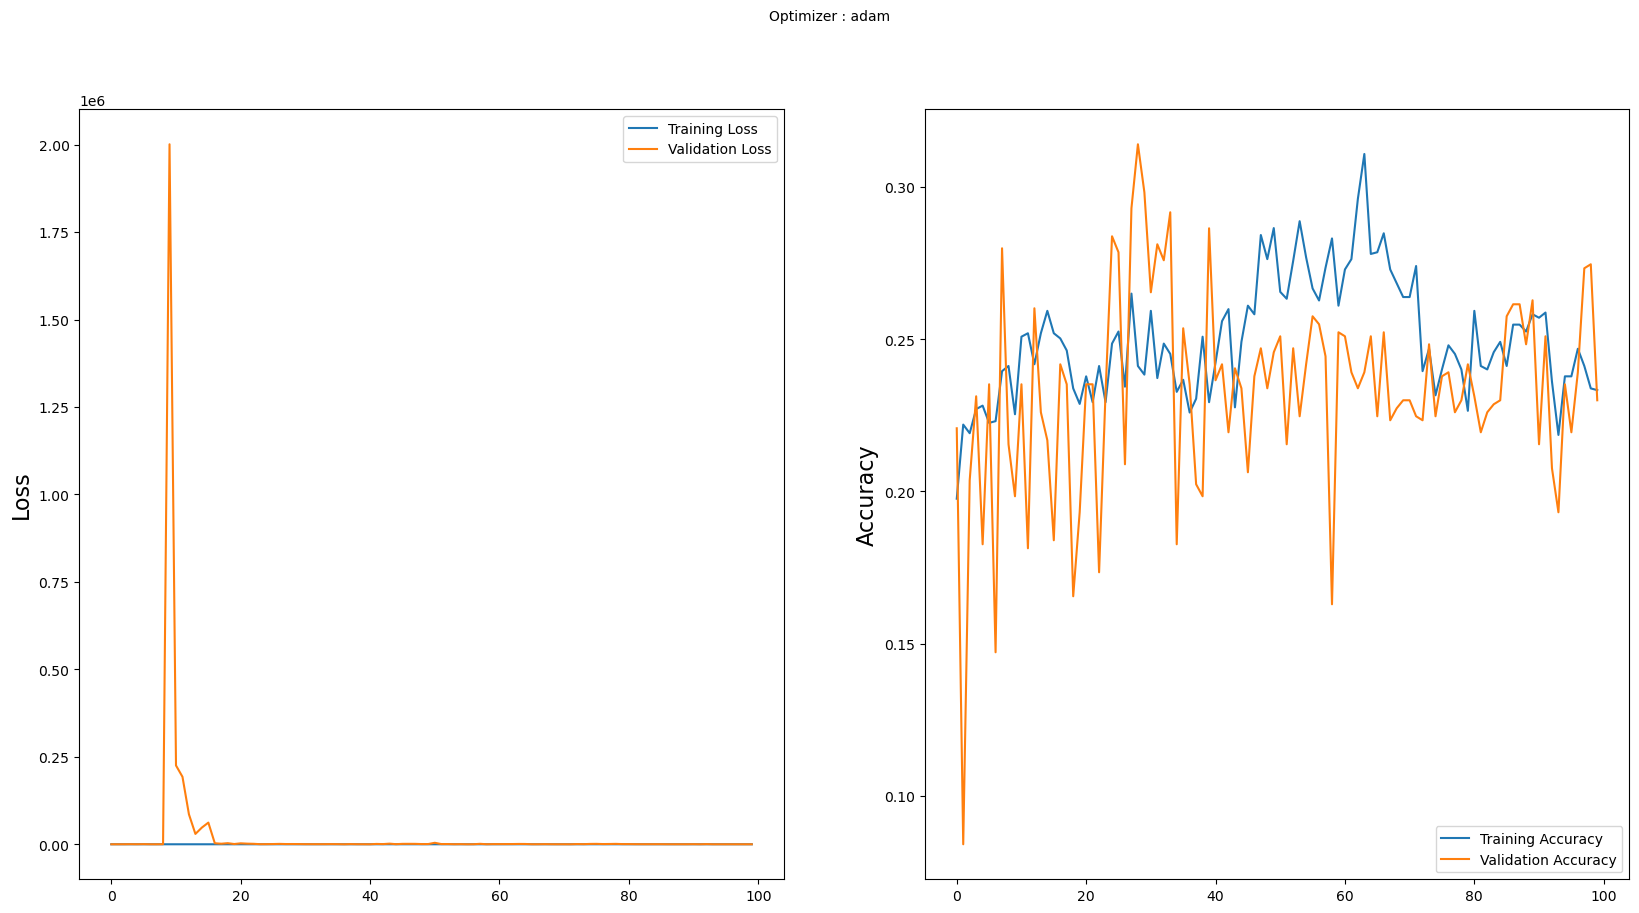

In [15]:
import matplotlib.pyplot as plt

x=hist1
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# GoogleNet

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers  import Concatenate
from tensorflow.keras.layers import AveragePooling2D, Dropout, Input, BatchNormalization
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from tqdm import tqdm
import urllib
from tensorflow.keras.preprocessing import image

In [17]:
def inceptionnet(x,filters):
    
    #(1x1) layer
    layer1=Conv2D(filters=filters[0],kernel_size=(1,1),strides=1,padding="same",activation="relu")(x)
    
    #(3x3) layer
    layer2=Conv2D(filters=filters[1][0],kernel_size=(1,1),strides=1,padding="same",activation="relu")(x)
    

    layer2=Conv2D(filters=filters[1][1],kernel_size=(1,1),strides=1,padding="same",activation="relu")(layer2)
    
    #(5x5) layer
    
    layer3=Conv2D(filters=filters[2][0],kernel_size=(5,5),strides=1,padding="same",activation="relu")(x)
    
    layers=Conv2D(filters=filters[2][1],kernel_size=(5,5),strides=1,padding="same",activation="relu")(layer3)
    
    
    
    layer4=MaxPooling2D(pool_size=(3,3),strides=1,padding="same")(x)
    layer4=Conv2D(filters=filters[3],kernel_size=(1,1),strides=1,padding="same",activation="relu")(layer4)
    
    
    return Concatenate(axis=-1)([layer1,layer2,layer3,layer4])
    
    
def helperfunction(x,name=None):
    
    layer=AveragePooling2D(pool_size=(5,5),strides=3,padding="valid")(x)
    
    layer=Conv2D(filters=128,kernel_size=(1,1),strides=1,padding="same",activation="relu")(layer)
    
    layer=Flatten()(layer)
    
    layer=Dense(units=255,activation="relu")(layer)
    
    layer=Dropout(0.4)(layer)
    layer=Dense(units=6,activation="softmax",name=name)(layer)
    
    return layer
    
       
def googlenet():
    
    #taking layer input
    inputlayer=Input(shape=(128,128,3))
    
    #layer_1
    layer=Conv2D(filters=64,kernel_size=(7,7),strides=1,padding="same",activation="relu")(inputlayer)
    
    layer=MaxPooling2D(pool_size=(3,3),strides=2,padding="same")(layer)
    
    layer=BatchNormalization()(layer)
    
    #layer_2
    layer=Conv2D(filters=64,kernel_size=(1,1),strides=1,padding="same",activation="relu")(layer)
    
    layer=Conv2D(filters=192,kernel_size=(3,3),strides=1,padding="same",activation="relu")(layer)
    
    layer=BatchNormalization()(layer)
    layer=MaxPooling2D(pool_size=(3,3),strides=2,padding="same")(layer)
    
    #layer_3
    layer=inceptionnet(layer,[64,(96,128),(16,32),32])
    layer=inceptionnet(layer,[128,(128,192),(32,96),64])
    layer=MaxPooling2D(pool_size=(3,3),strides=2,padding="same")(layer)
    
    #layer_4
    layer=inceptionnet(layer,[192,(96,208),(16,48),64])
    final_0=helperfunction(layer,name="final_layer_0")
    
    layer=inceptionnet(layer,[160,(112,224),(24,64),64])
    layer=inceptionnet(layer,[128,(128,256),(24,64),64])
    layer=inceptionnet(layer,[112,(144,288),(32,64),64])
    final_1=helperfunction(layer,name="final_layer_1")
    
    layer=inceptionnet(layer,[256,(160,320),(32,128),128])
    layer=MaxPooling2D(pool_size=(3,3),strides=2,padding="same")(layer)
    
    
    #layer_5
    layer=inceptionnet(layer,[256,(160,320),(32,128),128])
    layer=inceptionnet(layer,[384,(192,384),(48,128),128])
    layer=AveragePooling2D(pool_size=(7,7),strides=1,padding="same")(layer)
    
    #layer_6
    
    layer=Flatten()(layer)
    layer=Dropout(0.4)(layer)
    layer=Dense(units=256,activation="linear")(layer)
    final_2=Dense(units=6,activation="softmax",name="final_layer_2")(layer)
    
    
    model=Model(inputs=inputlayer,outputs=[final_2,final_0,final_1])
    
    return model

In [18]:
model2=googlenet()
model2.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_94 (Conv2D)             (None, 128, 128, 64  9472        ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 max_pooling2d_4 (MaxPooling2D)  (None, 64, 64, 64)  0           ['conv2d_94[0][0]']              
                                                                                            

 conv2d_118 (Conv2D)            (None, 16, 16, 224)  25312       ['conv2d_117[0][0]']             
                                                                                                  
 conv2d_119 (Conv2D)            (None, 16, 16, 24)   288024      ['concatenate_4[0][0]']          
                                                                                                  
 conv2d_121 (Conv2D)            (None, 16, 16, 64)   30784       ['max_pooling2d_10[0][0]']       
                                                                                                  
 concatenate_5 (Concatenate)    (None, 16, 16, 472)  0           ['conv2d_116[0][0]',             
                                                                  'conv2d_118[0][0]',             
                                                                  'conv2d_119[0][0]',             
                                                                  'conv2d_121[0][0]']             
          

                                                                  'conv2d_144[0][0]',             
                                                                  'conv2d_146[0][0]']             
                                                                                                  
 conv2d_148 (Conv2D)            (None, 8, 8, 192)    141504      ['concatenate_9[0][0]']          
                                                                                                  
 max_pooling2d_16 (MaxPooling2D  (None, 8, 8, 736)   0           ['concatenate_9[0][0]']          
 )                                                                                                
                                                                                                  
 conv2d_147 (Conv2D)            (None, 8, 8, 384)    283008      ['concatenate_9[0][0]']          
                                                                                                  
 conv2d_14

In [19]:
model2.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

In [20]:
hist2 = model2.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set))#,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
883/883 [==============================] - 38s 40ms/step - loss: 5.4878 - final_layer_2_loss: 2.0168 - final_layer_0_loss: 1.7285 - final_layer_1_loss: 1.7424 - final_layer_2_accuracy: 0.2152 - final_layer_2_f1_m: 0.0019 - final_layer_2_precision_m: 0.0023 - final_layer_2_recall_m: 0.0017 - final_layer_0_accuracy: 0.2792 - final_layer_0_f1_m: 0.0308 - final_layer_0_precision_m: 0.0447 - final_layer_0_recall_m: 0.0238 - final_layer_1_accuracy: 0.2186 - final_layer_1_f1_m: 0.0021 - final_layer_1_precision_m: 0.0028 - final_layer_1_recall_m: 0.0017 - val_loss: 5.1347 - val_final_layer_2_loss: 1.7286 - val_final_layer_0_loss: 1.6796 - val_final_layer_1_loss: 1.7264 - val_final_layer_2_accuracy: 0.1984 - val_final_layer_2_f1_m: 0.0000e+00 - val_final_layer_2_precision_m: 0.0000e+00 - val_final_layer_2_recall_m: 0.0000e+00 - val_final_layer_0_accuracy: 0.2589 - val_final_layer_0_f1_m: 0.0035 - val_final_layer_0_precision_m: 0.0052 - val_final_layer_0_recall_m: 0.0026 - val_final_

883/883 [==============================] - 34s 39ms/step - loss: 4.0175 - final_layer_2_loss: 1.7374 - final_layer_0_loss: 1.0829 - final_layer_1_loss: 1.1972 - final_layer_2_accuracy: 0.2276 - final_layer_2_f1_m: 0.0000e+00 - final_layer_2_precision_m: 0.0000e+00 - final_layer_2_recall_m: 0.0000e+00 - final_layer_0_accuracy: 0.5883 - final_layer_0_f1_m: 0.4768 - final_layer_0_precision_m: 0.5934 - final_layer_0_recall_m: 0.4185 - final_layer_1_accuracy: 0.5470 - final_layer_1_f1_m: 0.3996 - final_layer_1_precision_m: 0.5238 - final_layer_1_recall_m: 0.3375 - val_loss: 4.4323 - val_final_layer_2_loss: 1.7241 - val_final_layer_0_loss: 1.3445 - val_final_layer_1_loss: 1.3637 - val_final_layer_2_accuracy: 0.2352 - val_final_layer_2_f1_m: 0.0000e+00 - val_final_layer_2_precision_m: 0.0000e+00 - val_final_layer_2_recall_m: 0.0000e+00 - val_final_layer_0_accuracy: 0.5151 - val_final_layer_0_f1_m: 0.4322 - val_final_layer_0_precision_m: 0.5302 - val_final_layer_0_recall_m: 0.3832 - val_final_

883/883 [==============================] - 35s 40ms/step - loss: 3.2981 - final_layer_2_loss: 1.7257 - final_layer_0_loss: 0.7269 - final_layer_1_loss: 0.8455 - final_layer_2_accuracy: 0.2333 - final_layer_2_f1_m: 0.0000e+00 - final_layer_2_precision_m: 0.0000e+00 - final_layer_2_recall_m: 0.0000e+00 - final_layer_0_accuracy: 0.7378 - final_layer_0_f1_m: 0.6927 - final_layer_0_precision_m: 0.7803 - final_layer_0_recall_m: 0.6489 - final_layer_1_accuracy: 0.6829 - final_layer_1_f1_m: 0.6363 - final_layer_1_precision_m: 0.7390 - final_layer_1_recall_m: 0.5849 - val_loss: 5.5140 - val_final_layer_2_loss: 1.7248 - val_final_layer_0_loss: 1.9437 - val_final_layer_1_loss: 1.8454 - val_final_layer_2_accuracy: 0.2352 - val_final_layer_2_f1_m: 0.0000e+00 - val_final_layer_2_precision_m: 0.0000e+00 - val_final_layer_2_recall_m: 0.0000e+00 - val_final_layer_0_accuracy: 0.4323 - val_final_layer_0_f1_m: 0.3885 - val_final_layer_0_precision_m: 0.4488 - val_final_layer_0_recall_m: 0.3583 - val_final_

883/883 [==============================] - 34s 39ms/step - loss: 2.3278 - final_layer_2_loss: 1.1393 - final_layer_0_loss: 0.5694 - final_layer_1_loss: 0.6192 - final_layer_2_accuracy: 0.5889 - final_layer_2_f1_m: 0.4740 - final_layer_2_precision_m: 0.5951 - final_layer_2_recall_m: 0.4134 - final_layer_0_accuracy: 0.7922 - final_layer_0_f1_m: 0.7707 - final_layer_0_precision_m: 0.8284 - final_layer_0_recall_m: 0.7418 - final_layer_1_accuracy: 0.7843 - final_layer_1_f1_m: 0.7478 - final_layer_1_precision_m: 0.8256 - final_layer_1_recall_m: 0.7089 - val_loss: 3.5967 - val_final_layer_2_loss: 1.1947 - val_final_layer_0_loss: 1.2817 - val_final_layer_1_loss: 1.1203 - val_final_layer_2_accuracy: 0.5637 - val_final_layer_2_f1_m: 0.3329 - val_final_layer_2_precision_m: 0.4528 - val_final_layer_2_recall_m: 0.2730 - val_final_layer_0_accuracy: 0.6426 - val_final_layer_0_f1_m: 0.6155 - val_final_layer_0_precision_m: 0.6785 - val_final_layer_0_recall_m: 0.5840 - val_final_layer_1_accuracy: 0.6347

883/883 [==============================] - 34s 39ms/step - loss: 1.8126 - final_layer_2_loss: 0.8911 - final_layer_0_loss: 0.4575 - final_layer_1_loss: 0.4639 - final_layer_2_accuracy: 0.6574 - final_layer_2_f1_m: 0.5961 - final_layer_2_precision_m: 0.6908 - final_layer_2_recall_m: 0.5487 - final_layer_0_accuracy: 0.8369 - final_layer_0_f1_m: 0.8252 - final_layer_0_precision_m: 0.8675 - final_layer_0_recall_m: 0.8041 - final_layer_1_accuracy: 0.8279 - final_layer_1_f1_m: 0.8111 - final_layer_1_precision_m: 0.8533 - final_layer_1_recall_m: 0.7899 - val_loss: 3.5755 - val_final_layer_2_loss: 1.0833 - val_final_layer_0_loss: 1.2751 - val_final_layer_1_loss: 1.2170 - val_final_layer_2_accuracy: 0.6452 - val_final_layer_2_f1_m: 0.5945 - val_final_layer_2_precision_m: 0.6837 - val_final_layer_2_recall_m: 0.5499 - val_final_layer_0_accuracy: 0.6899 - val_final_layer_0_f1_m: 0.6724 - val_final_layer_0_precision_m: 0.7047 - val_final_layer_0_recall_m: 0.6562 - val_final_layer_1_accuracy: 0.6465

883/883 [==============================] - 34s 39ms/step - loss: 1.6320 - final_layer_2_loss: 0.8470 - final_layer_0_loss: 0.3577 - final_layer_1_loss: 0.4273 - final_layer_2_accuracy: 0.7293 - final_layer_2_f1_m: 0.6812 - final_layer_2_precision_m: 0.7650 - final_layer_2_recall_m: 0.6393 - final_layer_0_accuracy: 0.8675 - final_layer_0_f1_m: 0.8618 - final_layer_0_precision_m: 0.8890 - final_layer_0_recall_m: 0.8482 - final_layer_1_accuracy: 0.8426 - final_layer_1_f1_m: 0.8280 - final_layer_1_precision_m: 0.8669 - final_layer_1_recall_m: 0.8086 - val_loss: 4.9592 - val_final_layer_2_loss: 1.5204 - val_final_layer_0_loss: 1.7550 - val_final_layer_1_loss: 1.6838 - val_final_layer_2_accuracy: 0.4823 - val_final_layer_2_f1_m: 0.4449 - val_final_layer_2_precision_m: 0.5210 - val_final_layer_2_recall_m: 0.4068 - val_final_layer_0_accuracy: 0.5138 - val_final_layer_0_f1_m: 0.4948 - val_final_layer_0_precision_m: 0.5262 - val_final_layer_0_recall_m: 0.4790 - val_final_layer_1_accuracy: 0.5716

883/883 [==============================] - 34s 39ms/step - loss: 1.2448 - final_layer_2_loss: 0.6286 - final_layer_0_loss: 0.2937 - final_layer_1_loss: 0.3225 - final_layer_2_accuracy: 0.7831 - final_layer_2_f1_m: 0.7531 - final_layer_2_precision_m: 0.8177 - final_layer_2_recall_m: 0.7208 - final_layer_0_accuracy: 0.8998 - final_layer_0_f1_m: 0.9003 - final_layer_0_precision_m: 0.9241 - final_layer_0_recall_m: 0.8884 - final_layer_1_accuracy: 0.8952 - final_layer_1_f1_m: 0.8849 - final_layer_1_precision_m: 0.9105 - final_layer_1_recall_m: 0.8720 - val_loss: 3.7004 - val_final_layer_2_loss: 1.1477 - val_final_layer_0_loss: 1.3803 - val_final_layer_1_loss: 1.1724 - val_final_layer_2_accuracy: 0.6373 - val_final_layer_2_f1_m: 0.5862 - val_final_layer_2_precision_m: 0.6457 - val_final_layer_2_recall_m: 0.5564 - val_final_layer_0_accuracy: 0.6833 - val_final_layer_0_f1_m: 0.6767 - val_final_layer_0_precision_m: 0.7021 - val_final_layer_0_recall_m: 0.6640 - val_final_layer_1_accuracy: 0.6649

883/883 [==============================] - 34s 38ms/step - loss: 1.0445 - final_layer_2_loss: 0.5332 - final_layer_0_loss: 0.2487 - final_layer_1_loss: 0.2626 - final_layer_2_accuracy: 0.8114 - final_layer_2_f1_m: 0.7943 - final_layer_2_precision_m: 0.8460 - final_layer_2_recall_m: 0.7684 - final_layer_0_accuracy: 0.9145 - final_layer_0_f1_m: 0.9128 - final_layer_0_precision_m: 0.9287 - final_layer_0_recall_m: 0.9049 - final_layer_1_accuracy: 0.9134 - final_layer_1_f1_m: 0.9073 - final_layer_1_precision_m: 0.9213 - final_layer_1_recall_m: 0.9003 - val_loss: 4.1545 - val_final_layer_2_loss: 1.2296 - val_final_layer_0_loss: 1.5055 - val_final_layer_1_loss: 1.4193 - val_final_layer_2_accuracy: 0.6531 - val_final_layer_2_f1_m: 0.6334 - val_final_layer_2_precision_m: 0.6903 - val_final_layer_2_recall_m: 0.6050 - val_final_layer_0_accuracy: 0.6846 - val_final_layer_0_f1_m: 0.6767 - val_final_layer_0_precision_m: 0.7100 - val_final_layer_0_recall_m: 0.6601 - val_final_layer_1_accuracy: 0.6794

In [5]:
dl_acc = hist2.history["val_final_layer_1_accuracy"][99]
dl_prec = hist2.history["val_final_layer_1_precision_m"][99]
dl_rec = hist2.history["val_final_layer_1_recall_m"][99]
dl_f1 = hist2.history["val_final_layer_1_f1_m"][99]

storeResults('GoogleNet',dl_acc,dl_prec,dl_rec,dl_f1)

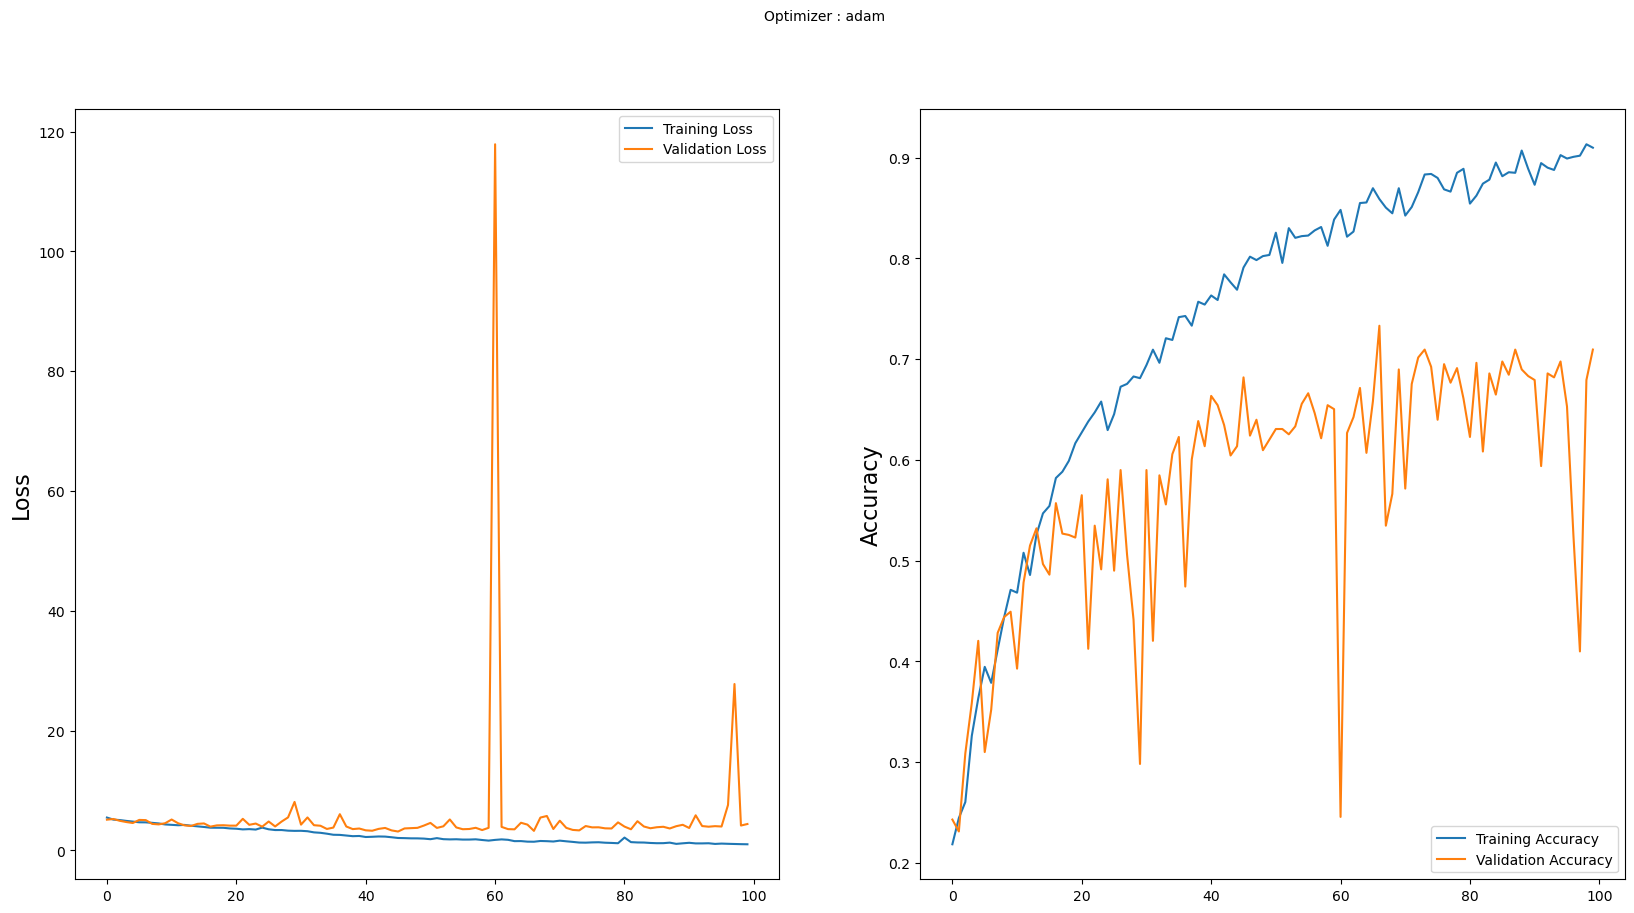

In [21]:
import matplotlib.pyplot as plt

x=hist2
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['final_layer_1_accuracy'], label='Training Accuracy')
plt.plot(x.history['val_final_layer_1_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# ResNet50

In [22]:
base_model = ResNet50(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(6, activation='softmax')(x1)
model3 = Model(inputs = base_model.inputs, outputs = prediction1)
model3.summary()
model3.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_3[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']       

 conv2_block3_2_conv (Conv2D)   (None, 32, 32, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 32, 32, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 32, 32, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_3_conv (Conv2D)   (None, 32, 32, 256)  16640       ['conv2_block3_2_relu[0][0]']    
                                                                                                  
 conv2_blo

 conv3_block3_2_conv (Conv2D)   (None, 16, 16, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_3_conv (Conv2D)   (None, 16, 16, 512)  66048       ['conv3_block3_2_relu[0][0]']    
                                                                                                  
 conv3_blo

 conv4_block2_2_conv (Conv2D)   (None, 8, 8, 256)    590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 8, 8, 256)   1024        ['conv4_block2_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block2_2_relu[0][0]']    
                                                                                                  
 conv4_blo

 conv4_block5_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block5_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block5_2_relu[0][0]']    
                                                                                                  
 conv4_block5_3_bn (BatchNormal  (None, 8, 8, 1024)  4096        ['conv4_block5_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_add (Add)         (None, 8, 8, 1024)   0           ['conv4_block4_out[0][0]',       
                                                                  'conv4_block5_3_bn[0][0]']      
          

 conv5_block2_2_relu (Activatio  (None, 4, 4, 512)   0           ['conv5_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_block2_3_conv (Conv2D)   (None, 4, 4, 2048)   1050624     ['conv5_block2_2_relu[0][0]']    
                                                                                                  
 conv5_block2_3_bn (BatchNormal  (None, 4, 4, 2048)  8192        ['conv5_block2_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_add (Add)         (None, 4, 4, 2048)   0           ['conv5_block1_out[0][0]',       
                                                                  'conv5_block2_3_bn[0][0]']      
          

In [23]:
hist3 = model3.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set))#,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
883/883 [==============================] - 39s 39ms/step - loss: 3.6214 - accuracy: 0.2203 - f1_m: 0.1099 - precision_m: 0.1472 - recall_m: 0.0912 - val_loss: 1.7523 - val_accuracy: 0.1932 - val_f1_m: 0.0017 - val_precision_m: 0.0026 - val_recall_m: 0.0013
Epoch 2/100
883/883 [==============================] - 34s 38ms/step - loss: 2.0257 - accuracy: 0.2356 - f1_m: 0.0791 - precision_m: 0.1172 - recall_m: 0.0600 - val_loss: 3.5663 - val_accuracy: 0.2352 - val_f1_m: 0.2362 - val_precision_m: 0.2362 - val_recall_m: 0.2362
Epoch 3/100
883/883 [==============================] - 34s 38ms/step - loss: 1.8566 - accuracy: 0.2599 - f1_m: 0.0647 - precision_m: 0.0946 - recall_m: 0.0498 - val_loss: 1.7428 - val_accuracy: 0.3325 - val_f1_m: 0.1623 - val_precision_m: 0.2244 - val_recall_m: 0.1312
Epoch 4/100
883/883 [==============================] - 34s 39ms/step - loss: 1.6248 - accuracy: 0.3420 - f1_m: 0.0919 - precision_m: 0.1308 - recall_m: 0.0725 - val_loss: 2.4176 - val_accuracy:

883/883 [==============================] - 30s 34ms/step - loss: 0.4694 - accuracy: 0.8352 - f1_m: 0.8267 - precision_m: 0.8550 - recall_m: 0.8126 - val_loss: 65.5966 - val_accuracy: 0.4468 - val_f1_m: 0.4344 - val_precision_m: 0.4528 - val_recall_m: 0.4252
Epoch 62/100
883/883 [==============================] - 30s 34ms/step - loss: 0.3701 - accuracy: 0.8715 - f1_m: 0.8632 - precision_m: 0.8862 - recall_m: 0.8516 - val_loss: 64.3292 - val_accuracy: 0.4678 - val_f1_m: 0.4528 - val_precision_m: 0.4764 - val_recall_m: 0.4409
Epoch 63/100
883/883 [==============================] - 30s 33ms/step - loss: 0.3909 - accuracy: 0.8681 - f1_m: 0.8647 - precision_m: 0.8907 - recall_m: 0.8516 - val_loss: 32.1898 - val_accuracy: 0.4836 - val_f1_m: 0.4711 - val_precision_m: 0.5000 - val_recall_m: 0.4567
Epoch 64/100
883/883 [==============================] - 30s 33ms/step - loss: 0.3792 - accuracy: 0.8562 - f1_m: 0.8528 - precision_m: 0.8754 - recall_m: 0.8414 - val_loss: 95.1687 - val_accuracy: 0.45

In [6]:
dl_acc = hist3.history["val_accuracy"][99]
dl_prec = hist3.history["val_precision_m"][99]
dl_rec = hist3.history["val_recall_m"][99]
dl_f1 = hist3.history["val_f1_m"][99]

storeResults('ResNet50',dl_acc,dl_prec,dl_rec,dl_f1)

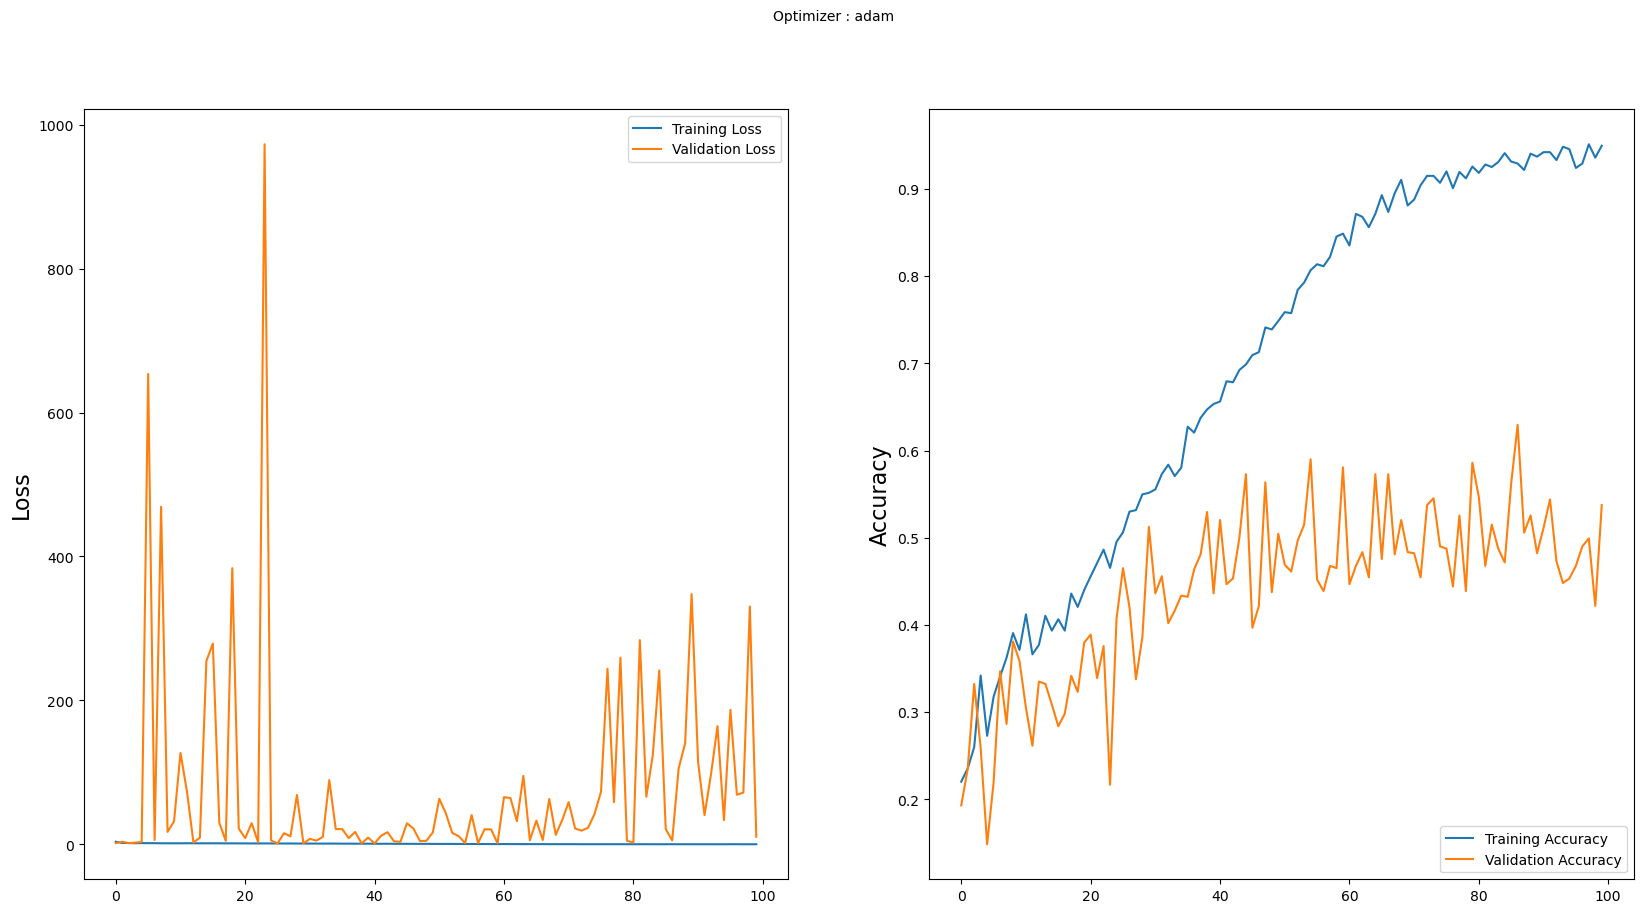

In [25]:
import matplotlib.pyplot as plt

x=hist3
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# MobileNetV2

In [12]:
base_model = MobileNetV2(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(6, activation='softmax')(x1)
model4 = Model(inputs = base_model.inputs, outputs = prediction1)
model4.summary()
model4.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 64, 64, 32)   864         ['input_1[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 64, 64, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)              (None, 64, 64, 32)   0           ['bn_Conv1[0][0]']           

 nv2D)                                                                                            
                                                                                                  
 block_3_depthwise_BN (BatchNor  (None, 16, 16, 144)  576        ['block_3_depthwise[0][0]']      
 malization)                                                                                      
                                                                                                  
 block_3_depthwise_relu (ReLU)  (None, 16, 16, 144)  0           ['block_3_depthwise_BN[0][0]']   
                                                                                                  
 block_3_project (Conv2D)       (None, 16, 16, 32)   4608        ['block_3_depthwise_relu[0][0]'] 
                                                                                                  
 block_3_project_BN (BatchNorma  (None, 16, 16, 32)  128         ['block_3_project[0][0]']        
 lization)

 ization)                                                                                         
                                                                                                  
 block_7_expand_relu (ReLU)     (None, 8, 8, 384)    0           ['block_7_expand_BN[0][0]']      
                                                                                                  
 block_7_depthwise (DepthwiseCo  (None, 8, 8, 384)   3456        ['block_7_expand_relu[0][0]']    
 nv2D)                                                                                            
                                                                                                  
 block_7_depthwise_BN (BatchNor  (None, 8, 8, 384)   1536        ['block_7_depthwise[0][0]']      
 malization)                                                                                      
                                                                                                  
 block_7_d

 block_10_project_BN (BatchNorm  (None, 8, 8, 96)    384         ['block_10_project[0][0]']       
 alization)                                                                                       
                                                                                                  
 block_11_expand (Conv2D)       (None, 8, 8, 576)    55296       ['block_10_project_BN[0][0]']    
                                                                                                  
 block_11_expand_BN (BatchNorma  (None, 8, 8, 576)   2304        ['block_11_expand[0][0]']        
 lization)                                                                                        
                                                                                                  
 block_11_expand_relu (ReLU)    (None, 8, 8, 576)    0           ['block_11_expand_BN[0][0]']     
                                                                                                  
 block_11_

                                                                                                  
 block_14_depthwise_relu (ReLU)  (None, 4, 4, 960)   0           ['block_14_depthwise_BN[0][0]']  
                                                                                                  
 block_14_project (Conv2D)      (None, 4, 4, 160)    153600      ['block_14_depthwise_relu[0][0]']
                                                                                                  
 block_14_project_BN (BatchNorm  (None, 4, 4, 160)   640         ['block_14_project[0][0]']       
 alization)                                                                                       
                                                                                                  
 block_14_add (Add)             (None, 4, 4, 160)    0           ['block_13_project_BN[0][0]',    
                                                                  'block_14_project_BN[0][0]']    
          

In [13]:
hist4 = model4.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set))#,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
883/883 [==============================] - 26s 25ms/step - loss: 3.2324 - accuracy: 0.3029 - f1_m: 0.2344 - precision_m: 0.2877 - recall_m: 0.2078 - val_loss: 17.2542 - val_accuracy: 0.2694 - val_f1_m: 0.2690 - val_precision_m: 0.2690 - val_recall_m: 0.2690
Epoch 2/100
883/883 [==============================] - 24s 27ms/step - loss: 1.4917 - accuracy: 0.4496 - f1_m: 0.3666 - precision_m: 0.4609 - recall_m: 0.3194 - val_loss: 3.5138 - val_accuracy: 0.3653 - val_f1_m: 0.3574 - val_precision_m: 0.3766 - val_recall_m: 0.3478
Epoch 3/100
883/883 [==============================] - 22s 25ms/step - loss: 1.2899 - accuracy: 0.4977 - f1_m: 0.4288 - precision_m: 0.5357 - recall_m: 0.3754 - val_loss: 2.1217 - val_accuracy: 0.5085 - val_f1_m: 0.4786 - val_precision_m: 0.5197 - val_recall_m: 0.4580
Epoch 4/100
883/883 [==============================] - 24s 27ms/step - loss: 1.2195 - accuracy: 0.5436 - f1_m: 0.4604 - precision_m: 0.5747 - recall_m: 0.4032 - val_loss: 5.2003 - val_accuracy

883/883 [==============================] - 24s 27ms/step - loss: 0.7287 - accuracy: 0.7633 - f1_m: 0.7590 - precision_m: 0.7945 - recall_m: 0.7412 - val_loss: 4.4221 - val_accuracy: 0.4494 - val_f1_m: 0.4326 - val_precision_m: 0.4580 - val_recall_m: 0.4199
Epoch 62/100
883/883 [==============================] - 24s 28ms/step - loss: 0.8486 - accuracy: 0.7418 - f1_m: 0.7331 - precision_m: 0.7656 - recall_m: 0.7169 - val_loss: 2.1063 - val_accuracy: 0.6570 - val_f1_m: 0.6365 - val_precision_m: 0.6601 - val_recall_m: 0.6247
Epoch 63/100
883/883 [==============================] - 25s 28ms/step - loss: 0.6569 - accuracy: 0.7809 - f1_m: 0.7726 - precision_m: 0.8001 - recall_m: 0.7588 - val_loss: 1.2845 - val_accuracy: 0.6531 - val_f1_m: 0.6308 - val_precision_m: 0.6693 - val_recall_m: 0.6115
Epoch 64/100
883/883 [==============================] - 25s 28ms/step - loss: 0.6599 - accuracy: 0.7950 - f1_m: 0.7816 - precision_m: 0.8080 - recall_m: 0.7684 - val_loss: 1.6772 - val_accuracy: 0.6544 -

In [7]:
dl_acc = hist4.history["val_accuracy"][99]
dl_prec = hist4.history["val_precision_m"][99] 
dl_rec = hist4.history["val_recall_m"][99] 
dl_f1 = hist4.history["val_f1_m"][99]

storeResults('MobileNetV2',dl_acc,dl_prec,dl_rec,dl_f1)

In [14]:
model4.save('mobile.h5')

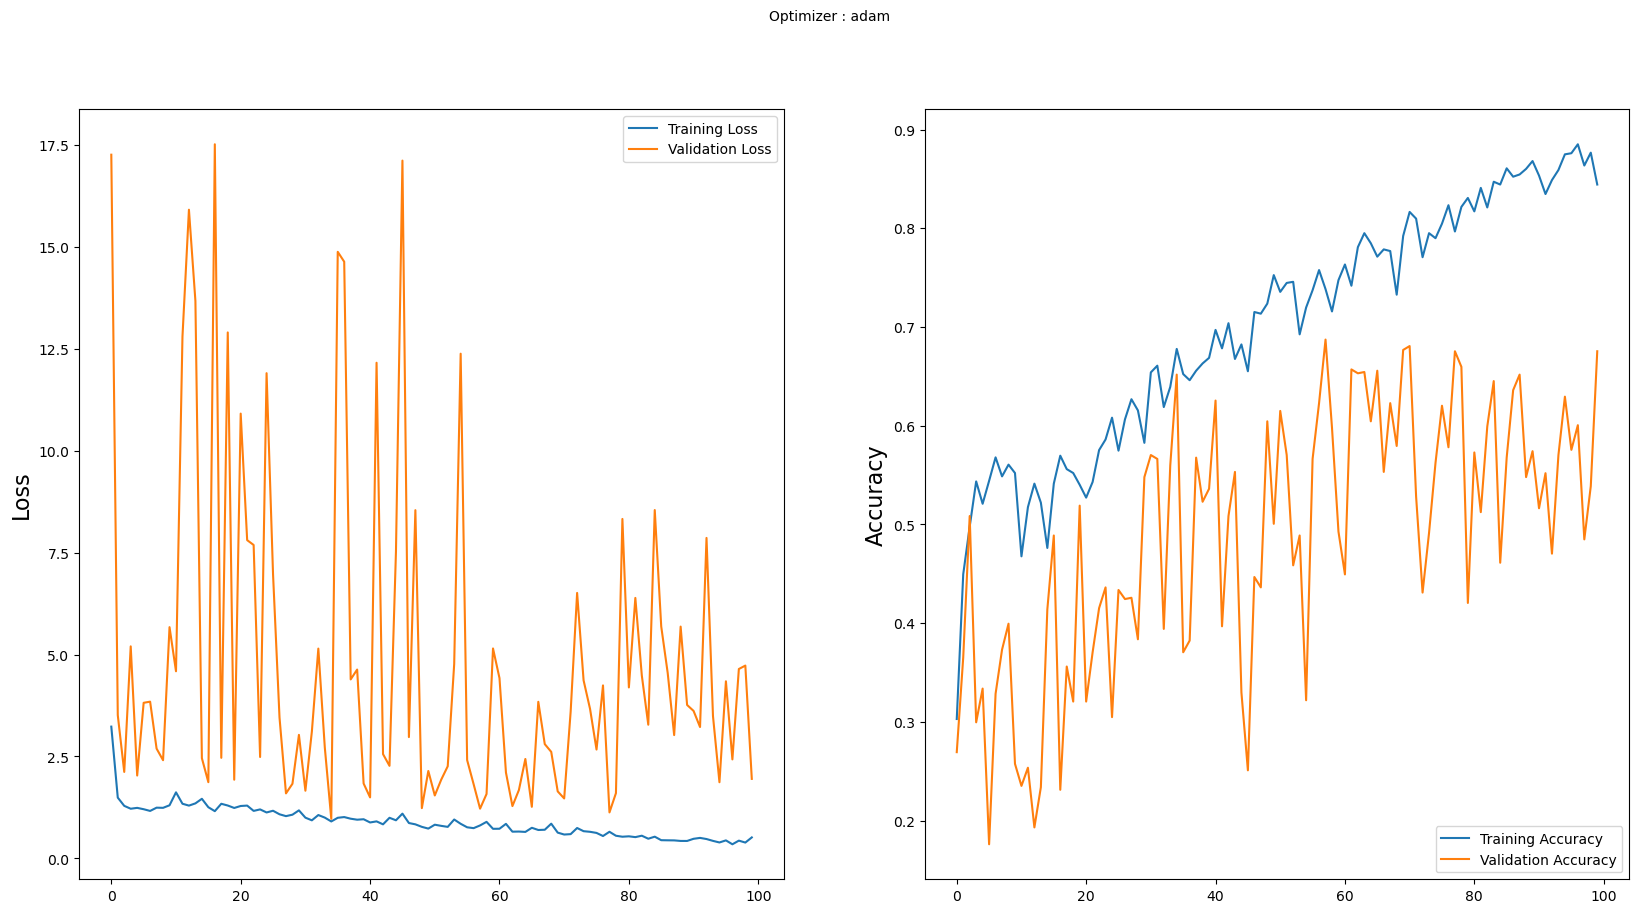

In [16]:
import matplotlib.pyplot as plt

x=hist4
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# DenseNet201

In [17]:
base_model = DenseNet201(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(6, activation='softmax')(x1)
model5 = Model(inputs = base_model.inputs, outputs = prediction1)
model5.summary()
model5.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 134, 134, 3)  0          ['input_2[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 64, 64, 64)   9408        ['zero_padding2d[0][0]']         
                                                                                                  
 conv1/bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1/conv[0][0]']       

                                                                                                  
 conv2_block4_1_bn (BatchNormal  (None, 32, 32, 128)  512        ['conv2_block4_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block4_1_relu (Activatio  (None, 32, 32, 128)  0          ['conv2_block4_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block4_2_conv (Conv2D)   (None, 32, 32, 32)   36864       ['conv2_block4_1_relu[0][0]']    
                                                                                                  
 conv2_block4_concat (Concatena  (None, 32, 32, 192)  0          ['conv2_block3_concat[0][0]',    
 te)      

 conv3_block2_1_conv (Conv2D)   (None, 16, 16, 128)  20480       ['conv3_block2_0_relu[0][0]']    
                                                                                                  
 conv3_block2_1_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block2_1_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block2_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block2_1_relu[0][0]']    
                                                                                                  
 conv3_blo

                                                                                                  
 conv3_block6_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block6_1_relu[0][0]']    
                                                                                                  
 conv3_block6_concat (Concatena  (None, 16, 16, 320)  0          ['conv3_block5_concat[0][0]',    
 te)                                                              'conv3_block6_2_conv[0][0]']    
                                                                                                  
 conv3_block7_0_bn (BatchNormal  (None, 16, 16, 320)  1280       ['conv3_block6_concat[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block7_0_relu (Activatio  (None, 16, 16, 320)  0          ['conv3_block7_0_bn[0][0]']      
 n)       

 lization)                                                                                        
                                                                                                  
 conv3_block11_0_relu (Activati  (None, 16, 16, 448)  0          ['conv3_block11_0_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv3_block11_1_conv (Conv2D)  (None, 16, 16, 128)  57344       ['conv3_block11_0_relu[0][0]']   
                                                                                                  
 conv3_block11_1_bn (BatchNorma  (None, 16, 16, 128)  512        ['conv3_block11_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv3_blo

...

 conv5_block15_2_conv (Conv2D)  (None, 4, 4, 32)     36864       ['conv5_block15_1_relu[0][0]']   
                                                                                                  
 conv5_block15_concat (Concaten  (None, 4, 4, 1376)  0           ['conv5_block14_concat[0][0]',   
 ate)                                                             'conv5_block15_2_conv[0][0]']   
                                                                                                  
 conv5_block16_0_bn (BatchNorma  (None, 4, 4, 1376)  5504        ['conv5_block15_concat[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv5_block16_0_relu (Activati  (None, 4, 4, 1376)  0           ['conv5_block16_0_bn[0][0]']     
 on)                                                                                              
          

                                                                                                  
 conv5_block20_0_relu (Activati  (None, 4, 4, 1504)  0           ['conv5_block20_0_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_block20_1_conv (Conv2D)  (None, 4, 4, 128)    192512      ['conv5_block20_0_relu[0][0]']   
                                                                                                  
 conv5_block20_1_bn (BatchNorma  (None, 4, 4, 128)   512         ['conv5_block20_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv5_block20_1_relu (Activati  (None, 4, 4, 128)   0           ['conv5_block20_1_bn[0][0]']     
 on)      

 lization)                                                                                        
                                                                                                  
 conv5_block24_1_relu (Activati  (None, 4, 4, 128)   0           ['conv5_block24_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_block24_2_conv (Conv2D)  (None, 4, 4, 32)     36864       ['conv5_block24_1_relu[0][0]']   
                                                                                                  
 conv5_block24_concat (Concaten  (None, 4, 4, 1664)  0           ['conv5_block23_concat[0][0]',   
 ate)                                                             'conv5_block24_2_conv[0][0]']   
                                                                                                  
 conv5_blo

 conv5_block28_concat (Concaten  (None, 4, 4, 1792)  0           ['conv5_block27_concat[0][0]',   
 ate)                                                             'conv5_block28_2_conv[0][0]']   
                                                                                                  
 conv5_block29_0_bn (BatchNorma  (None, 4, 4, 1792)  7168        ['conv5_block28_concat[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv5_block29_0_relu (Activati  (None, 4, 4, 1792)  0           ['conv5_block29_0_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_block29_1_conv (Conv2D)  (None, 4, 4, 128)    229376      ['conv5_block29_0_relu[0][0]']   
          

 flatten_1 (Flatten)            (None, 30720)        0           ['relu[0][0]']                   
                                                                                                  
 dense_1 (Dense)                (None, 6)            184326      ['flatten_1[0][0]']              
                                                                                                  
Total params: 18,506,310
Trainable params: 18,277,254
Non-trainable params: 229,056
__________________________________________________________________________________________________


In [18]:
hist5 = model5.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set))#,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
883/883 [==============================] - 125s 127ms/step - loss: 6.8597 - accuracy: 0.2242 - f1_m: 0.2078 - precision_m: 0.2237 - recall_m: 0.1999 - val_loss: 3.9124 - val_accuracy: 0.2773 - val_f1_m: 0.2725 - val_precision_m: 0.2927 - val_recall_m: 0.2625
Epoch 2/100
883/883 [==============================] - 109s 124ms/step - loss: 2.6903 - accuracy: 0.3171 - f1_m: 0.2833 - precision_m: 0.3188 - recall_m: 0.2656 - val_loss: 4.6812 - val_accuracy: 0.3903 - val_f1_m: 0.3871 - val_precision_m: 0.4081 - val_recall_m: 0.3766
Epoch 3/100
883/883 [==============================] - 110s 124ms/step - loss: 1.9238 - accuracy: 0.3488 - f1_m: 0.2880 - precision_m: 0.3522 - recall_m: 0.2559 - val_loss: 8.8621 - val_accuracy: 0.2260 - val_f1_m: 0.1789 - val_precision_m: 0.2060 - val_recall_m: 0.1654
Epoch 4/100
883/883 [==============================] - 110s 125ms/step - loss: 1.7070 - accuracy: 0.3760 - f1_m: 0.2726 - precision_m: 0.3522 - recall_m: 0.2327 - val_loss: 13.4701 - val_

883/883 [==============================] - 110s 124ms/step - loss: 0.1629 - accuracy: 0.9422 - f1_m: 0.9377 - precision_m: 0.9445 - recall_m: 0.9343 - val_loss: 2.1650 - val_accuracy: 0.6386 - val_f1_m: 0.6382 - val_precision_m: 0.6601 - val_recall_m: 0.6273
Epoch 62/100
883/883 [==============================] - 111s 125ms/step - loss: 0.1418 - accuracy: 0.9473 - f1_m: 0.9466 - precision_m: 0.9530 - recall_m: 0.9434 - val_loss: 2.0838 - val_accuracy: 0.6360 - val_f1_m: 0.6304 - val_precision_m: 0.6470 - val_recall_m: 0.6220
Epoch 63/100
883/883 [==============================] - 110s 125ms/step - loss: 0.1633 - accuracy: 0.9451 - f1_m: 0.9453 - precision_m: 0.9502 - recall_m: 0.9428 - val_loss: 1.4872 - val_accuracy: 0.6820 - val_f1_m: 0.6807 - val_precision_m: 0.7008 - val_recall_m: 0.6706
Epoch 64/100
883/883 [==============================] - 110s 125ms/step - loss: 0.1419 - accuracy: 0.9507 - f1_m: 0.9500 - precision_m: 0.9541 - recall_m: 0.9479 - val_loss: 2.2018 - val_accuracy: 

In [8]:
dl_acc = hist5.history["val_accuracy"][99]
dl_prec = hist5.history["val_precision_m"][99] 
dl_rec = hist5.history["val_recall_m"][99] 
dl_f1 = hist5.history["val_f1_m"][99]

storeResults('DenseNet201',dl_acc,dl_prec,dl_rec,dl_f1)

In [19]:
model5.save('dense.h5')

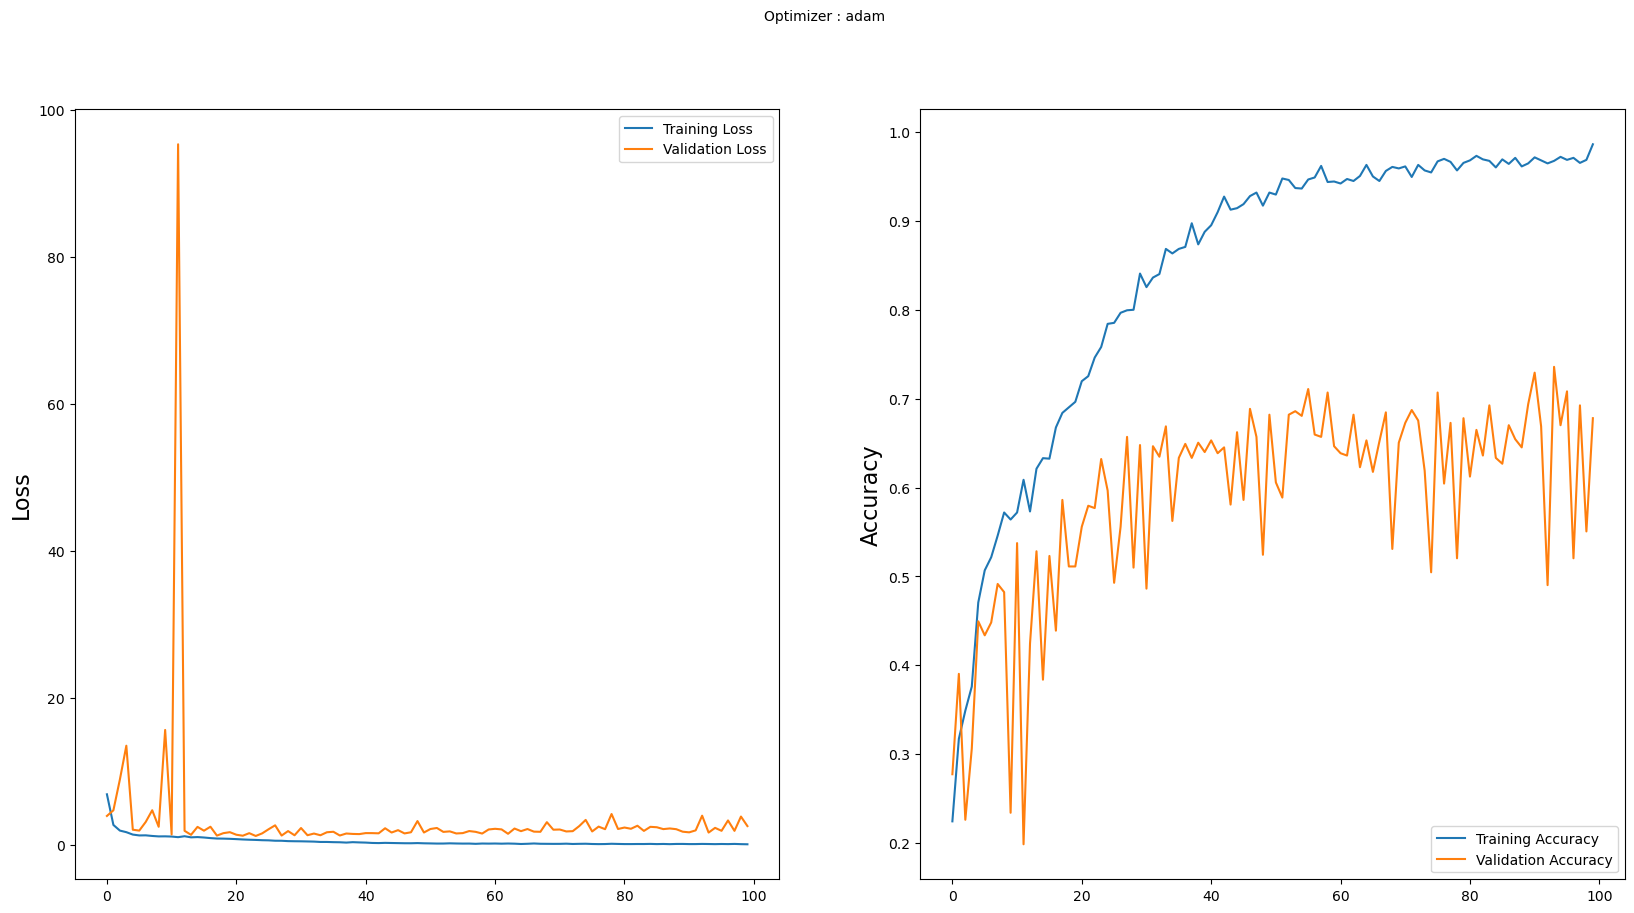

In [20]:
import matplotlib.pyplot as plt

x=hist5
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# MobileNet + DenseNet

In [21]:
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Average
import efficientnet.keras 
def ensemble():

    model_1 = load_model('mobile.h5', compile=False)
    model_1 = Model(inputs = model_1.inputs, outputs = model_1.outputs, name = 'MobileNet')

    model_2 = load_model('dense.h5', compile=False)
    model_2 = Model(inputs = model_2.inputs, outputs = model_2.outputs, name = 'DenseNet')
    
    models = [model_1, model_2]


    models_input = Input(shape =(128,128,3))
    models_output = [model(models_input) for model in models]
    
    ensemble_output = Average()(models_output)

    simple_average = Model(inputs = models_input, outputs = ensemble_output, name = 'Ensemble')

    return simple_average

In [22]:
proposed = ensemble()
proposed.compile(optimizer='sgd', 
              loss = 'categorical_crossentropy', 
              metrics=["accuracy",f1_m,precision_m, recall_m])
proposed.summary()

Model: "Ensemble"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 MobileNet (Functional)         (None, 6)            2380870     ['input_3[0][0]']                
                                                                                                  
 DenseNet (Functional)          (None, 6)            18506310    ['input_3[0][0]']                
                                                                                                  
 average (Average)              (None, 6)            0           ['MobileNet[0][0]',       

In [23]:
hist6 = proposed.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set))#,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
381/381 [==============================] - 76s 164ms/step - loss: 1.3085 - accuracy: 0.6018 - f1_m: 0.5341 - precision_m: 0.6312 - recall_m: 0.4856 - val_loss: 1.6875 - val_accuracy: 0.5572 - val_f1_m: 0.4300 - val_precision_m: 0.5394 - val_recall_m: 0.3753
Epoch 2/100
381/381 [==============================] - 60s 157ms/step - loss: 1.2058 - accuracy: 0.4625 - f1_m: 0.4396 - precision_m: 0.4895 - recall_m: 0.4147 - val_loss: 1.5424 - val_accuracy: 0.3929 - val_f1_m: 0.3491 - val_precision_m: 0.3990 - val_recall_m: 0.3241
Epoch 3/100
381/381 [==============================] - 61s 159ms/step - loss: 1.0821 - accuracy: 0.4323 - f1_m: 0.4029 - precision_m: 0.4370 - recall_m: 0.3858 - val_loss: 1.1213 - val_accuracy: 0.6478 - val_f1_m: 0.5687 - val_precision_m: 0.7008 - val_recall_m: 0.5026
Epoch 4/100
381/381 [==============================] - 60s 158ms/step - loss: 0.9667 - accuracy: 0.4468 - f1_m: 0.4248 - precision_m: 0.4606 - recall_m: 0.4068 - val_loss: 0.9862 - val_accur

381/381 [==============================] - 61s 159ms/step - loss: 0.2058 - accuracy: 0.9080 - f1_m: 0.8880 - precision_m: 0.9265 - recall_m: 0.8688 - val_loss: 0.4368 - val_accuracy: 0.8804 - val_f1_m: 0.8508 - val_precision_m: 0.8990 - val_recall_m: 0.8268
Epoch 62/100
381/381 [==============================] - 60s 156ms/step - loss: 0.1907 - accuracy: 0.9146 - f1_m: 0.8955 - precision_m: 0.9278 - recall_m: 0.8793 - val_loss: 0.4270 - val_accuracy: 0.8660 - val_f1_m: 0.8377 - val_precision_m: 0.8858 - val_recall_m: 0.8136
Epoch 63/100
381/381 [==============================] - 59s 156ms/step - loss: 0.1784 - accuracy: 0.9304 - f1_m: 0.9081 - precision_m: 0.9423 - recall_m: 0.8911 - val_loss: 0.4045 - val_accuracy: 0.8765 - val_f1_m: 0.8526 - val_precision_m: 0.9042 - val_recall_m: 0.8268
Epoch 64/100
381/381 [==============================] - 60s 159ms/step - loss: 0.2167 - accuracy: 0.8975 - f1_m: 0.8841 - precision_m: 0.9199 - recall_m: 0.8661 - val_loss: 0.4317 - val_accuracy: 0.85

In [9]:
dl_acc = hist6.history["val_accuracy"][99]
dl_prec = hist6.history["val_precision_m"][99] 
dl_rec = hist6.history["val_recall_m"][99] 
dl_f1 = hist6.history["val_f1_m"][99]

storeResults('Proposed',dl_acc,dl_prec,dl_rec,dl_f1)

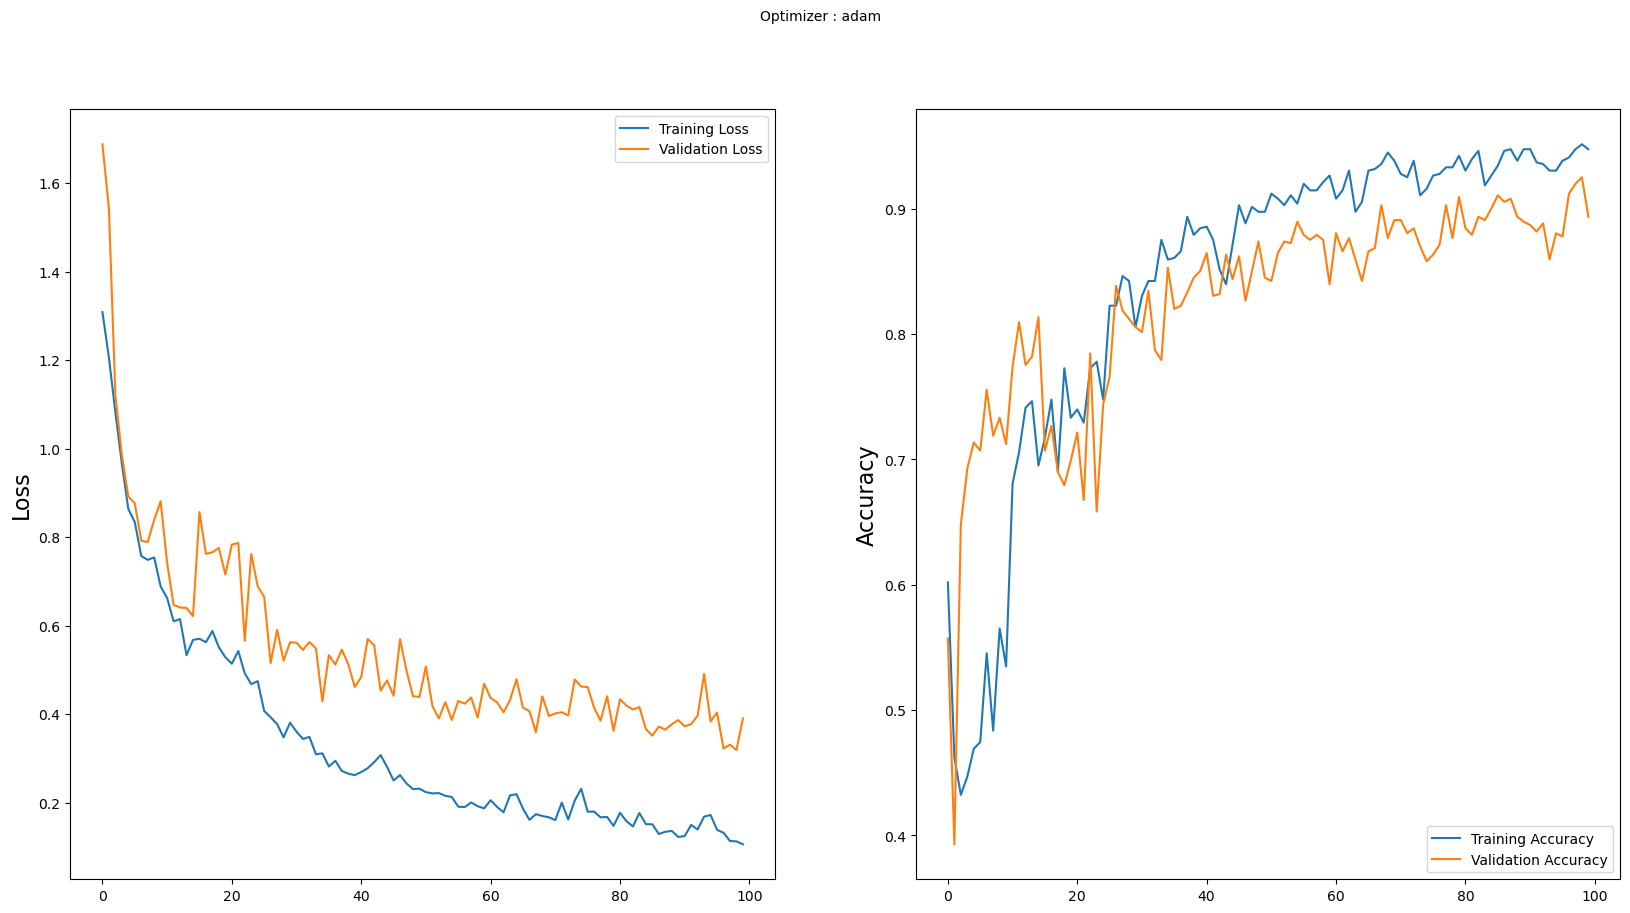

In [24]:
import matplotlib.pyplot as plt

x=hist6
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# Xception

In [25]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.layers import Activation, Dense,GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [26]:
# Defining the pretrained base model
base = Xception(include_top=False, weights='imagenet', input_shape=(128,128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
# Defining the head of the model where the prediction is conducted
head = Dense(6, activation='softmax')(x)
# Combining base and head 
model7 = Model(inputs=base.input, outputs=head)

In [27]:
model7.compile(optimizer='sgd', 
              loss = 'categorical_crossentropy', 
              metrics=["accuracy",f1_m,precision_m, recall_m])
model7.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 63, 63, 32)   864         ['input_4[0][0]']                
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 63, 63, 32)  128         ['block1_conv1[0][0]']           
 ation)                                                                                           
                                                                                            

 n)                                                                                               
                                                                                                  
 block4_sepconv2 (SeparableConv  (None, 16, 16, 728)  536536     ['block4_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block4_sepconv2_bn (BatchNorma  (None, 16, 16, 728)  2912       ['block4_sepconv2[0][0]']        
 lization)                                                                                        
                                                                                                  
 conv2d_2 (Conv2D)              (None, 8, 8, 728)    186368      ['add_1[0][0]']                  
                                                                                                  
 block4_po

                                                                                                  
 block7_sepconv1_bn (BatchNorma  (None, 8, 8, 728)   2912        ['block7_sepconv1[0][0]']        
 lization)                                                                                        
                                                                                                  
 block7_sepconv2_act (Activatio  (None, 8, 8, 728)   0           ['block7_sepconv1_bn[0][0]']     
 n)                                                                                               
                                                                                                  
 block7_sepconv2 (SeparableConv  (None, 8, 8, 728)   536536      ['block7_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block7_se

                                                                  'add_6[0][0]']                  
                                                                                                  
 block10_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_7[0][0]']                  
 on)                                                                                              
                                                                                                  
 block10_sepconv1 (SeparableCon  (None, 8, 8, 728)   536536      ['block10_sepconv1_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block10_sepconv1_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block10_sepconv1[0][0]']       
 alization)                                                                                       
          

 block12_sepconv3 (SeparableCon  (None, 8, 8, 728)   536536      ['block12_sepconv3_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block12_sepconv3_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block12_sepconv3[0][0]']       
 alization)                                                                                       
                                                                                                  
 add_10 (Add)                   (None, 8, 8, 728)    0           ['block12_sepconv3_bn[0][0]',    
                                                                  'add_9[0][0]']                  
                                                                                                  
 block13_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_10[0][0]']                 
 on)      

In [28]:
hist7 = model7.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set))#,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
381/381 [==============================] - 16s 35ms/step - loss: 1.7212 - accuracy: 0.2523 - f1_m: 0.0122 - precision_m: 0.0184 - recall_m: 0.0092 - val_loss: 1.5538 - val_accuracy: 0.4100 - val_f1_m: 0.0621 - val_precision_m: 0.0919 - val_recall_m: 0.0472
Epoch 2/100
381/381 [==============================] - 12s 33ms/step - loss: 1.5113 - accuracy: 0.4021 - f1_m: 0.1247 - precision_m: 0.1850 - recall_m: 0.0945 - val_loss: 1.1567 - val_accuracy: 0.5979 - val_f1_m: 0.3666 - val_precision_m: 0.4961 - val_recall_m: 0.3018
Epoch 3/100
381/381 [==============================] - 12s 32ms/step - loss: 1.2627 - accuracy: 0.5138 - f1_m: 0.3386 - precision_m: 0.4724 - recall_m: 0.2717 - val_loss: 0.8830 - val_accuracy: 0.7083 - val_f1_m: 0.5713 - val_precision_m: 0.7270 - val_recall_m: 0.4934
Epoch 4/100
381/381 [==============================] - 12s 32ms/step - loss: 1.0233 - accuracy: 0.6189 - f1_m: 0.5131 - precision_m: 0.6575 - recall_m: 0.4409 - val_loss: 0.5670 - val_accuracy:

381/381 [==============================] - 12s 33ms/step - loss: 0.0106 - accuracy: 0.9974 - f1_m: 0.9974 - precision_m: 0.9974 - recall_m: 0.9974 - val_loss: 0.0087 - val_accuracy: 0.9974 - val_f1_m: 0.9978 - val_precision_m: 0.9987 - val_recall_m: 0.9974
Epoch 62/100
381/381 [==============================] - 12s 32ms/step - loss: 0.0026 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0083 - val_accuracy: 0.9987 - val_f1_m: 0.9978 - val_precision_m: 0.9987 - val_recall_m: 0.9974
Epoch 63/100
381/381 [==============================] - 12s 32ms/step - loss: 0.0017 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0074 - val_accuracy: 0.9974 - val_f1_m: 0.9978 - val_precision_m: 0.9987 - val_recall_m: 0.9974
Epoch 64/100
381/381 [==============================] - 12s 32ms/step - loss: 0.0038 - accuracy: 0.9987 - f1_m: 0.9991 - precision_m: 1.0000 - recall_m: 0.9987 - val_loss: 0.0082 - val_accuracy: 0.9974 -

In [10]:
dl_acc = hist7.history["val_accuracy"][99]
dl_prec = hist7.history["val_precision_m"][99] 
dl_rec = hist7.history["val_recall_m"][99] 
dl_f1 = hist7.history["val_f1_m"][99]

storeResults('Xception',dl_acc,dl_prec,dl_rec,dl_f1)

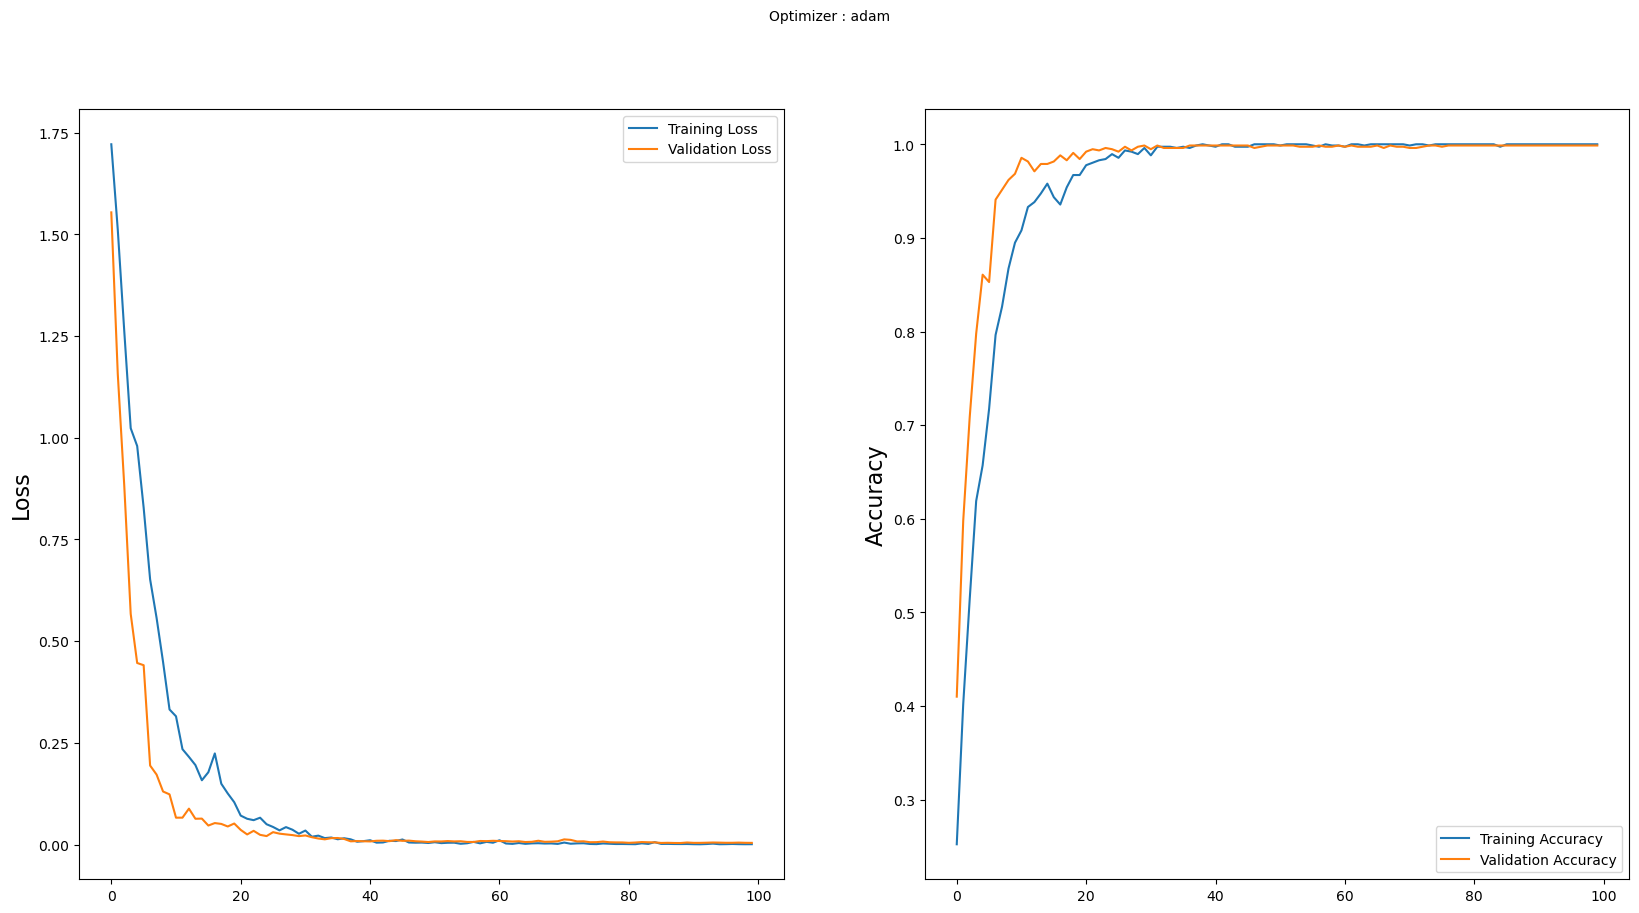

In [30]:
import matplotlib.pyplot as plt

x=hist7
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

In [31]:
model7.save('xcep.h5')

# NaseNetMobile

In [32]:
# Defining the pretrained base model
base = NASNetMobile(include_top=False, weights='imagenet', input_shape=(128,128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
# Defining the head of the model where the prediction is conducted
head = Dense(6, activation='softmax')(x)
# Combining base and head 
model8 = Model(inputs=base.input, outputs=head)

In [33]:
model8.compile(optimizer='sgd', 
              loss = 'categorical_crossentropy', 
              metrics=["accuracy",f1_m,precision_m, recall_m])
model8.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 stem_conv1 (Conv2D)            (None, 63, 63, 32)   864         ['input_5[0][0]']                
                                                                                                  
 stem_bn1 (BatchNormalization)  (None, 63, 63, 32)   128         ['stem_conv1[0][0]']             
                                                                                                  
 activation (Activation)        (None, 63, 63, 32)   0           ['stem_bn1[0][0]']         

 right2_stem_1 (BatchNormalizat                                  t2_stem_1[0][0]']                
 ion)                                                                                             
                                                                                                  
 separable_conv_1_reduction_rig  (None, 32, 32, 11)  1152        ['separable_conv_1_pad_reduction_
 ht3_stem_1 (SeparableConv2D)                                    right3_stem_1[0][0]']            
                                                                                                  
 separable_conv_1_reduction_lef  (None, 32, 32, 11)  220         ['activation_9[0][0]']           
 t4_stem_1 (SeparableConv2D)                                                                      
                                                                                                  
 activation_6 (Activation)      (None, 32, 32, 11)   0           ['separable_conv_1_bn_reduction_r
          

 cropping2d (Cropping2D)        (None, 63, 63, 32)   0           ['zero_padding2d_2[0][0]']       
                                                                                                  
 reduction_concat_stem_1 (Conca  (None, 32, 32, 44)  0           ['reduction_add_2_stem_1[0][0]', 
 tenate)                                                          'reduction_add3_stem_1[0][0]',  
                                                                  'add_12[0][0]',                 
                                                                  'reduction_add4_stem_1[0][0]']  
                                                                                                  
 adjust_avg_pool_1_stem_2 (Aver  (None, 32, 32, 32)  0           ['adjust_relu_1_stem_2[0][0]']   
 agePooling2D)                                                                                    
                                                                                                  
 adjust_av

                                                                                                  
 reduction_add_1_stem_2 (Add)   (None, 16, 16, 22)   0           ['separable_conv_2_bn_reduction_l
                                                                 eft1_stem_2[0][0]',              
                                                                  'separable_conv_2_bn_reduction_r
                                                                 ight1_stem_2[0][0]']             
                                                                                                  
 separable_conv_1_reduction_rig  (None, 16, 16, 22)  1562        ['separable_conv_1_pad_reduction_
 ht2_stem_2 (SeparableConv2D)                                    right2_stem_2[0][0]']            
                                                                                                  
 separable_conv_1_pad_reduction  (None, 35, 35, 22)  0           ['activation_18[0][0]']          
 _right3_s

 zero_padding2d_3 (ZeroPadding2  (None, 33, 33, 44)  0           ['adjust_relu_1_0[0][0]']        
 D)                                                                                               
                                                                                                  
 reduction_add3_stem_2 (Add)    (None, 16, 16, 22)   0           ['reduction_left3_stem_2[0][0]', 
                                                                  'separable_conv_2_bn_reduction_r
                                                                 ight3_stem_2[0][0]']             
                                                                                                  
 add_13 (Add)                   (None, 16, 16, 22)   0           ['reduction_add_2_stem_2[0][0]', 
                                                                  'reduction_left4_stem_2[0][0]'] 
                                                                                                  
 reduction

...

                                                                                                  
 separable_conv_1_normal_right2  (None, 4, 4, 176)   32560       ['activation_159[0][0]']         
 _10 (SeparableConv2D)                                                                            
                                                                                                  
 separable_conv_1_normal_left5_  (None, 4, 4, 176)   32560       ['activation_161[0][0]']         
 10 (SeparableConv2D)                                                                             
                                                                                                  
 separable_conv_1_bn_normal_lef  (None, 4, 4, 176)   704         ['separable_conv_1_normal_left1_1
 t1_10 (BatchNormalization)                                      0[0][0]']                        
                                                                                                  
 separable

                                                                  'separable_conv_2_bn_normal_righ
                                                                 t2_10[0][0]']                    
                                                                                                  
 normal_add_3_10 (Add)          (None, 4, 4, 176)    0           ['normal_left3_10[0][0]',        
                                                                  'adjust_bn_10[0][0]']           
                                                                                                  
 normal_add_4_10 (Add)          (None, 4, 4, 176)    0           ['normal_left4_10[0][0]',        
                                                                  'normal_right4_10[0][0]']       
                                                                                                  
 normal_add_5_10 (Add)          (None, 4, 4, 176)    0           ['separable_conv_2_bn_normal_left
          

                                                                                                  
 activation_172 (Activation)    (None, 4, 4, 176)    0           ['separable_conv_1_bn_normal_righ
                                                                 t2_11[0][0]']                    
                                                                                                  
 activation_174 (Activation)    (None, 4, 4, 176)    0           ['separable_conv_1_bn_normal_left
                                                                 5_11[0][0]']                     
                                                                                                  
 separable_conv_2_normal_left1_  (None, 4, 4, 176)   35376       ['activation_166[0][0]']         
 11 (SeparableConv2D)                                                                             
                                                                                                  
 separable

 on)                                                             ']                               
                                                                                                  
 normal_bn_1_12 (BatchNormaliza  (None, 4, 4, 176)   704         ['normal_conv_1_12[0][0]']       
 tion)                                                                                            
                                                                                                  
 activation_177 (Activation)    (None, 4, 4, 176)    0           ['normal_bn_1_12[0][0]']         
                                                                                                  
 activation_179 (Activation)    (None, 4, 4, 176)    0           ['adjust_bn_12[0][0]']           
                                                                                                  
 activation_181 (Activation)    (None, 4, 4, 176)    0           ['adjust_bn_12[0][0]']           
          

                                                                                                  
 separable_conv_2_bn_normal_rig  (None, 4, 4, 176)   704         ['separable_conv_2_normal_right2_
 ht2_12 (BatchNormalization)                                     12[0][0]']                       
                                                                                                  
 normal_left3_12 (AveragePoolin  (None, 4, 4, 176)   0           ['normal_bn_1_12[0][0]']         
 g2D)                                                                                             
                                                                                                  
 normal_left4_12 (AveragePoolin  (None, 4, 4, 176)   0           ['adjust_bn_12[0][0]']           
 g2D)                                                                                             
                                                                                                  
 normal_ri

In [34]:
hist8 = model8.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set))#,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
381/381 [==============================] - 71s 151ms/step - loss: 1.5704 - accuracy: 0.3995 - f1_m: 0.2485 - precision_m: 0.3360 - recall_m: 0.2047 - val_loss: 1.7502 - val_accuracy: 0.3706 - val_f1_m: 0.2572 - val_precision_m: 0.3176 - val_recall_m: 0.2270
Epoch 2/100
381/381 [==============================] - 54s 142ms/step - loss: 1.2365 - accuracy: 0.5519 - f1_m: 0.4112 - precision_m: 0.5328 - recall_m: 0.3504 - val_loss: 1.8061 - val_accuracy: 0.4455 - val_f1_m: 0.3889 - val_precision_m: 0.4685 - val_recall_m: 0.3491
Epoch 3/100
381/381 [==============================] - 55s 144ms/step - loss: 1.0567 - accuracy: 0.6097 - f1_m: 0.5306 - precision_m: 0.6522 - recall_m: 0.4698 - val_loss: 2.7767 - val_accuracy: 0.2891 - val_f1_m: 0.2673 - val_precision_m: 0.3005 - val_recall_m: 0.2507
Epoch 4/100
381/381 [==============================] - 55s 144ms/step - loss: 0.8980 - accuracy: 0.6754 - f1_m: 0.6317 - precision_m: 0.7402 - recall_m: 0.5774 - val_loss: 1.6559 - val_accur

381/381 [==============================] - 55s 145ms/step - loss: 3.9172e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.1185 - val_accuracy: 0.9869 - val_f1_m: 0.9882 - val_precision_m: 0.9908 - val_recall_m: 0.9869
Epoch 62/100
381/381 [==============================] - 55s 144ms/step - loss: 0.0018 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.1155 - val_accuracy: 0.9882 - val_f1_m: 0.9873 - val_precision_m: 0.9882 - val_recall_m: 0.9869
Epoch 63/100
381/381 [==============================] - 55s 144ms/step - loss: 6.0069e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.1153 - val_accuracy: 0.9895 - val_f1_m: 0.9891 - val_precision_m: 0.9908 - val_recall_m: 0.9882
Epoch 64/100
381/381 [==============================] - 55s 145ms/step - loss: 7.0223e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0978 - val_ac

381/381 [==============================] - 55s 144ms/step - loss: 5.2935e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0915 - val_accuracy: 0.9869 - val_f1_m: 0.9873 - val_precision_m: 0.9882 - val_recall_m: 0.9869
Epoch 92/100
381/381 [==============================] - 55s 144ms/step - loss: 3.3751e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0955 - val_accuracy: 0.9869 - val_f1_m: 0.9873 - val_precision_m: 0.9882 - val_recall_m: 0.9869
Epoch 93/100
381/381 [==============================] - 55s 145ms/step - loss: 5.8390e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.1044 - val_accuracy: 0.9855 - val_f1_m: 0.9851 - val_precision_m: 0.9869 - val_recall_m: 0.9843
Epoch 94/100
381/381 [==============================] - 55s 144ms/step - loss: 7.6405e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0999 - va

In [11]:
dl_acc = hist8.history["val_accuracy"][99]
dl_prec = hist8.history["val_precision_m"][99] 
dl_rec = hist8.history["val_recall_m"][99] 
dl_f1 = hist8.history["val_f1_m"][99]

storeResults('NASNetMobile',dl_acc,dl_prec,dl_rec,dl_f1)

In [35]:
model8.save('nasnet.h5')

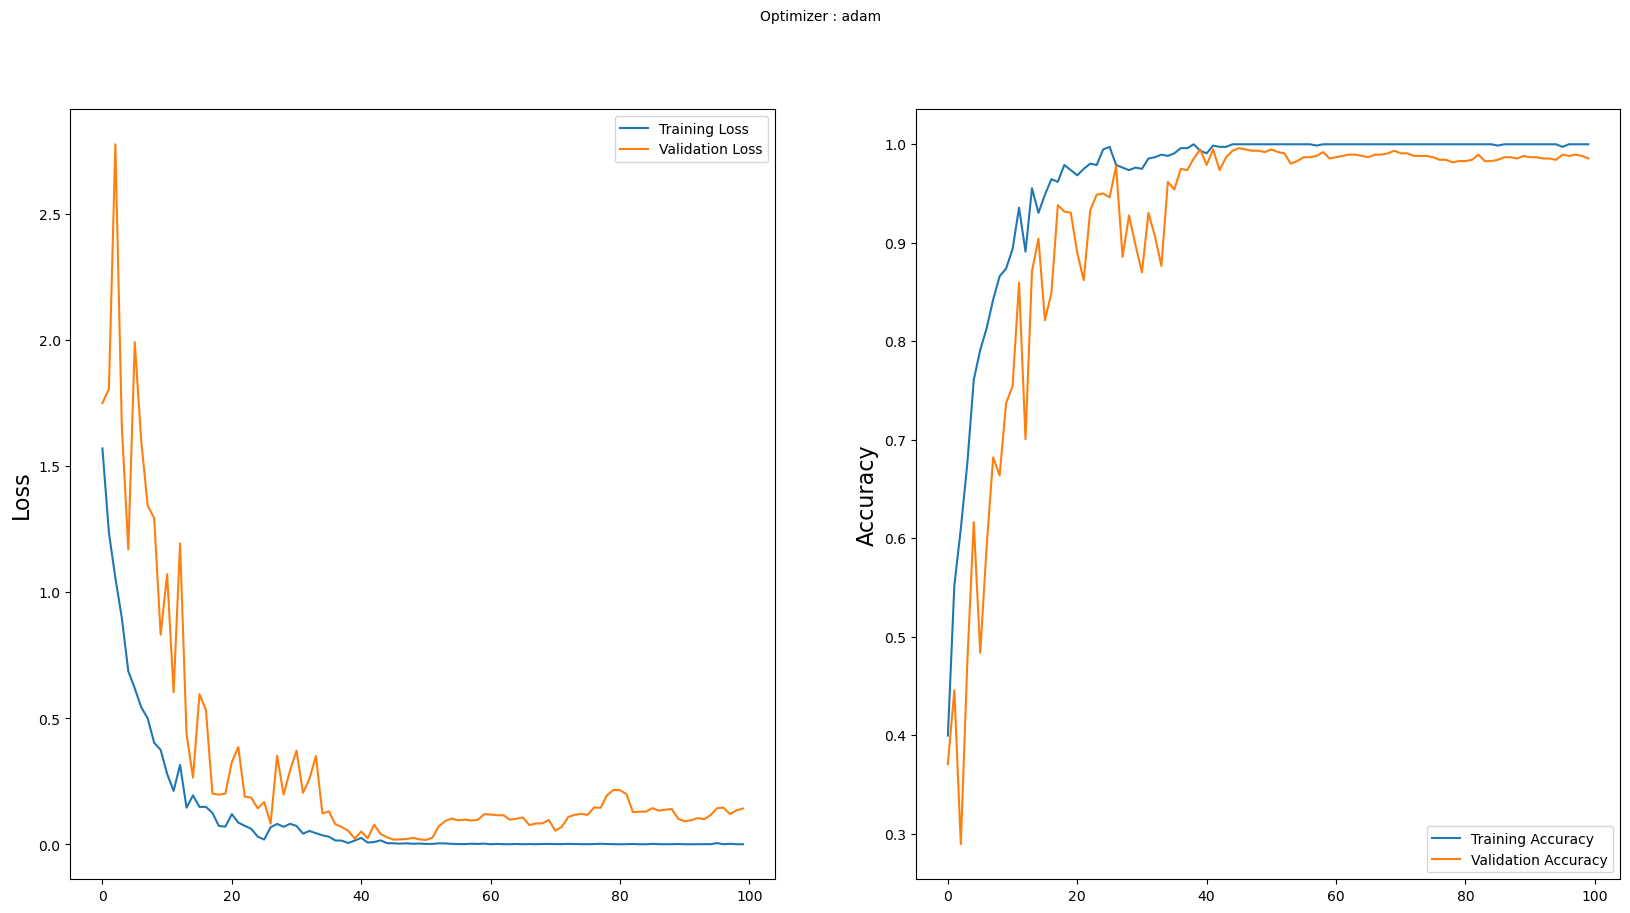

In [36]:
import matplotlib.pyplot as plt

x=hist8
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# Ensemble

In [37]:
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Average
import efficientnet.keras 
def ensemble():

    model_1 = load_model('xcep.h5', compile=False)
    model_1 = Model(inputs = model_1.inputs, outputs = model_1.outputs, name = 'Xception')

    model_2 = load_model('nasnet.h5', compile=False)
    model_2 = Model(inputs = model_2.inputs, outputs = model_2.outputs, name = 'NaseNet')
    
    models = [model_1, model_2]


    models_input = Input(shape =(128,128,3))
    models_output = [model(models_input) for model in models]
    
    ensemble_output = Average()(models_output)

    simple_average = Model(inputs = models_input, outputs = ensemble_output, name = 'Ensemble')

    return simple_average

In [38]:
ext = ensemble()
ext.compile(optimizer='sgd', 
              loss = 'categorical_crossentropy', 
              metrics=["accuracy",f1_m,precision_m, recall_m])
ext.summary()

Model: "Ensemble"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Xception (Functional)          (None, 6)            20873774    ['input_6[0][0]']                
                                                                                                  
 NaseNet (Functional)           (None, 6)            4276058     ['input_6[0][0]']                
                                                                                                  
 average_1 (Average)            (None, 6)            0           ['Xception[0][0]',        

In [39]:
history = ext.fit(
    train_set,
    epochs=100,
    validation_data=test_set)#,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
381/381 [==============================] - 91s 198ms/step - loss: 6.3842e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0114 - val_accuracy: 0.9987 - val_f1_m: 0.9969 - val_precision_m: 0.9987 - val_recall_m: 0.9961
Epoch 2/100
381/381 [==============================] - 72s 189ms/step - loss: 5.9779e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0109 - val_accuracy: 0.9987 - val_f1_m: 0.9969 - val_precision_m: 0.9987 - val_recall_m: 0.9961
Epoch 3/100
381/381 [==============================] - 72s 190ms/step - loss: 9.1169e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0117 - val_accuracy: 0.9987 - val_f1_m: 0.9969 - val_precision_m: 0.9987 - val_recall_m: 0.9961
Epoch 4/100
381/381 [==============================] - 71s 186ms/step - loss: 0.0013 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0117

Epoch 31/100
381/381 [==============================] - 72s 189ms/step - loss: 7.3979e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0116 - val_accuracy: 0.9987 - val_f1_m: 0.9969 - val_precision_m: 0.9987 - val_recall_m: 0.9961
Epoch 32/100
381/381 [==============================] - 72s 190ms/step - loss: 4.3460e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0124 - val_accuracy: 0.9987 - val_f1_m: 0.9974 - val_precision_m: 1.0000 - val_recall_m: 0.9961
Epoch 33/100
381/381 [==============================] - 72s 188ms/step - loss: 3.9304e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0123 - val_accuracy: 0.9987 - val_f1_m: 0.9974 - val_precision_m: 1.0000 - val_recall_m: 0.9961
Epoch 34/100
381/381 [==============================] - 72s 190ms/step - loss: 0.0011 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.

Epoch 61/100
381/381 [==============================] - 71s 187ms/step - loss: 3.9586e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0126 - val_accuracy: 0.9987 - val_f1_m: 0.9965 - val_precision_m: 1.0000 - val_recall_m: 0.9948
Epoch 62/100
381/381 [==============================] - 71s 186ms/step - loss: 3.0843e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0126 - val_accuracy: 0.9987 - val_f1_m: 0.9965 - val_precision_m: 1.0000 - val_recall_m: 0.9948
Epoch 63/100
381/381 [==============================] - 72s 190ms/step - loss: 7.4811e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0136 - val_accuracy: 0.9987 - val_f1_m: 0.9969 - val_precision_m: 0.9987 - val_recall_m: 0.9961
Epoch 64/100
381/381 [==============================] - 72s 189ms/step - loss: 7.6090e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss

Epoch 91/100
381/381 [==============================] - 71s 187ms/step - loss: 6.9083e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0128 - val_accuracy: 1.0000 - val_f1_m: 0.9965 - val_precision_m: 1.0000 - val_recall_m: 0.9948
Epoch 92/100
381/381 [==============================] - 72s 188ms/step - loss: 2.7816e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0129 - val_accuracy: 1.0000 - val_f1_m: 0.9965 - val_precision_m: 1.0000 - val_recall_m: 0.9948
Epoch 93/100
381/381 [==============================] - 72s 189ms/step - loss: 2.8880e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0125 - val_accuracy: 1.0000 - val_f1_m: 0.9974 - val_precision_m: 1.0000 - val_recall_m: 0.9961
Epoch 94/100
381/381 [==============================] - 72s 189ms/step - loss: 3.1566e-04 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss

In [12]:
dl_acc = history.history["val_accuracy"][99]
dl_prec = history.history["val_precision_m"][99] 
dl_rec = history.history["val_recall_m"][99] 
dl_f1 = history.history["val_f1_m"][99]

storeResults('Extension',dl_acc,dl_prec,dl_rec,dl_f1)

In [40]:
ext.save('ensemble.h5')

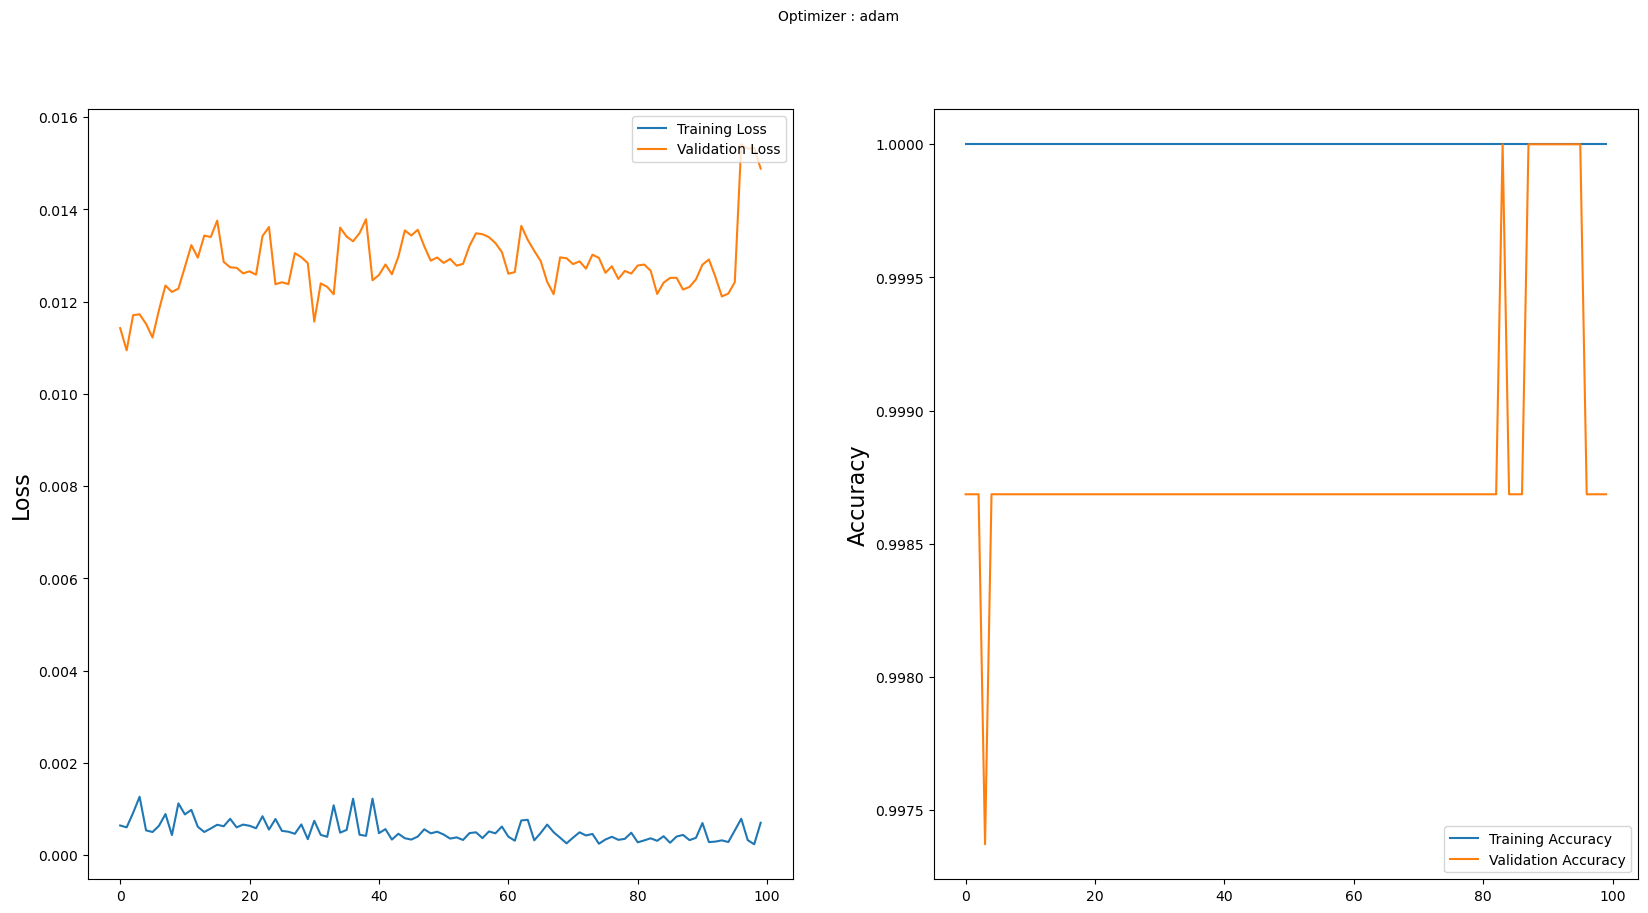

In [41]:
import matplotlib.pyplot as plt

x=history
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# Comparison

In [13]:
#creating dataframe
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'Recall'   : recall, 
                       'F1_score' : f1score,
                        
                        
                      })

In [14]:
result

,ML Model,Accuracy,Precision,Recall,F1_score
0,InceptionV3,0.233,0.189,0.144,0.159
1,GoogleNet,0.710,0.730,0.694,0.706
2,ResNet50,0.537,0.543,0.529,0.534
3,MobileNetV2,0.675,0.701,0.659,0.673
4,DenseNet201,0.678,0.685,0.676,0.679
5,Proposed,0.894,0.920,0.849,0.873
6,Xception,0.999,0.999,0.999,0.999
7,NASNetMobile,0.986,0.986,0.986,0.986
8,Extension,0.999,1.000,0.996,0.997


# Graph

In [15]:
import numpy as np
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

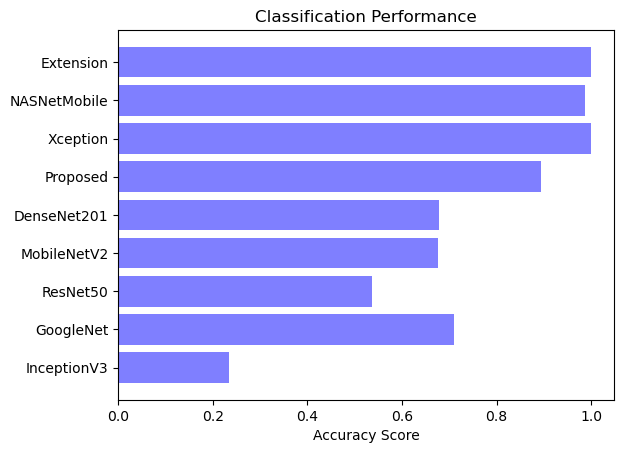

In [16]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

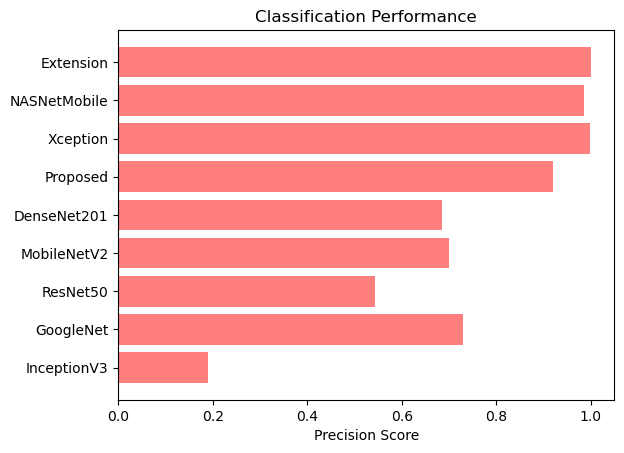

In [17]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

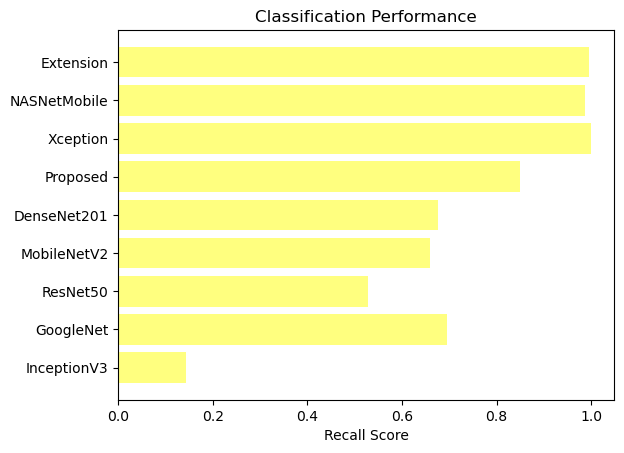

In [18]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

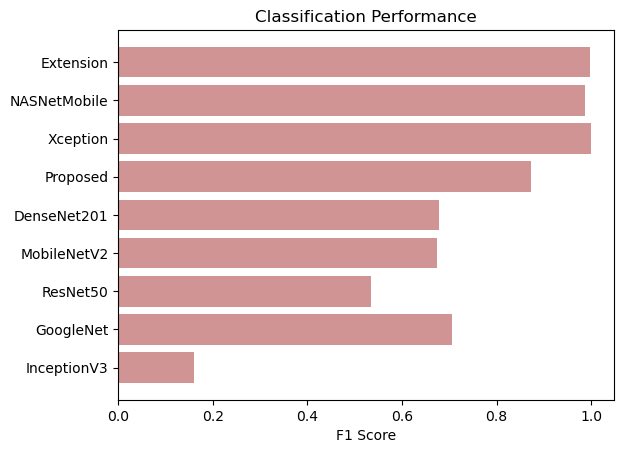

In [19]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()